# Analysis of ChIP-seq simulation

See `chips` folder for scripts.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tempfile
from itertools import product
from statannotations.Annotator import Annotator
from tqdm.auto import tqdm

sns.set_style("whitegrid")
sns.set_context("paper", rc={"font.size": 8})

In [2]:
PATH = os.path.expanduser('~/data/2025_chips')
N = 10
MULTIPLIERS = [1.0, 0.7, 0.5, 0.2, 0.1]

FIGURES_DIR = f'{PATH}/pics'
! mkdir -p {FIGURES_DIR}
! rm {FIGURES_DIR}/*

# Chips models analysis

In [3]:
import json

models_df = pd.DataFrame(columns=['Modification', 'Model', 'k', 'theta', 'prc_rate', 'f', 's'],
                         dtype=object)
for modification in ['H3K27ac', 'H3K27me3', 'H3K36me3', 'H3K4me1', 'H3K4me3']:
    path = os.path.join(PATH, 'models', f'{modification}.json')
    with open(path) as f_with_control:
        m = json.load(f_with_control)
        k, theta, prc_rate, f_with_control, s = m['frag']['k'], m['frag']['theta'], m['pcr_rate'], \
            m['pulldown']['f'], m['pulldown']['s']
        models_df.loc[len(models_df)] = (modification, path, k, theta, prc_rate, f_with_control, s)
models_df.to_csv(os.path.join(PATH, 'models.tsv'), sep='\t', index=None)
models_df

,Modification,Model,k,theta,prc_rate,f,s
0,H3K27ac,/home/jetbrains/data/2025_chips/models/H3K27ac...,9.698845,28.720036,1.0,0.016691,0.543023
1,H3K27me3,/home/jetbrains/data/2025_chips/models/H3K27me...,7.710403,32.211166,1.0,0.003799,0.186056
2,H3K36me3,/home/jetbrains/data/2025_chips/models/H3K36me...,8.121823,31.384718,1.0,0.021185,0.649353
3,H3K4me1,/home/jetbrains/data/2025_chips/models/H3K4me1...,7.084311,33.604404,1.0,0.016509,0.742254
4,H3K4me3,/home/jetbrains/data/2025_chips/models/H3K4me3...,5.655991,37.608902,1.0,0.005437,0.738595


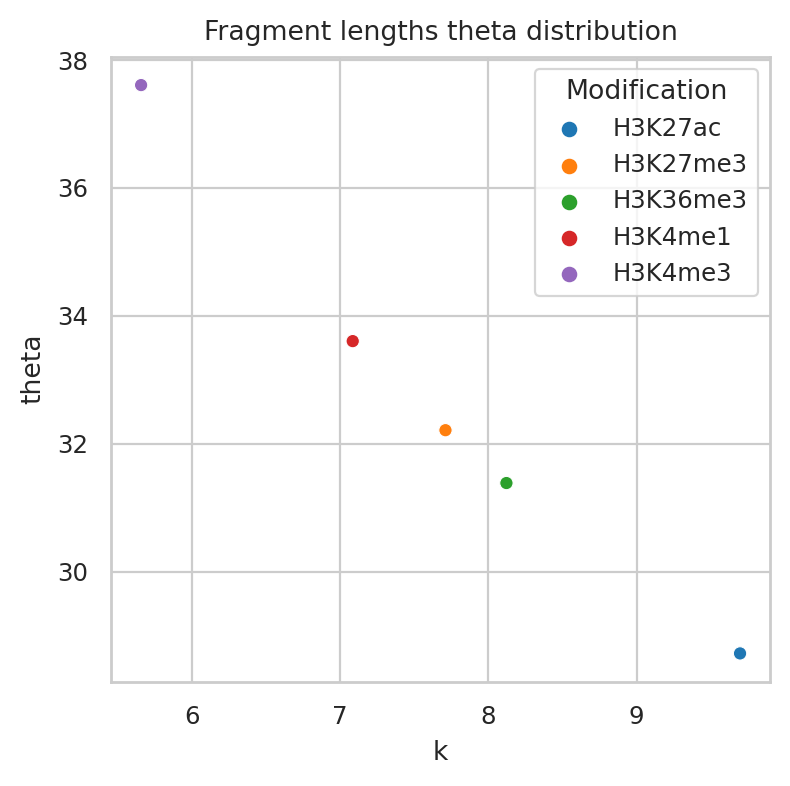

In [4]:
fig = plt.figure(figsize=(4, 4))
sns.scatterplot(data=models_df, x='k', y='theta', hue='Modification', markers=True)
plt.title(f'Fragment lengths theta distribution')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'models_fragments_theta.pdf'), bbox_inches='tight', dpi=300)
plt.show()

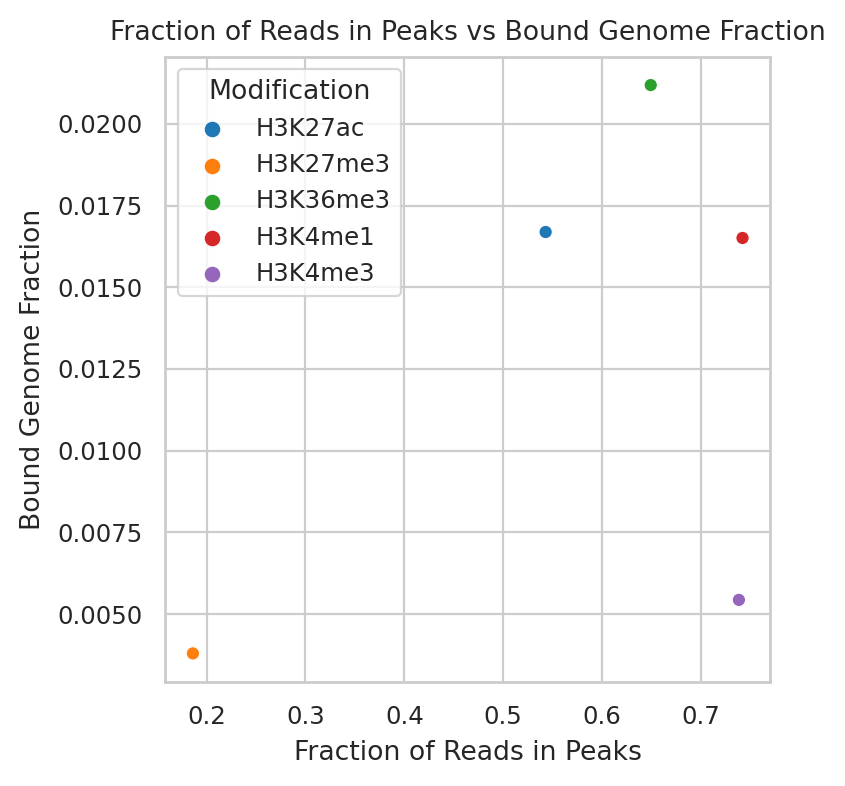

In [5]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=models_df, x='s', y='f', hue='Modification', markers=True)
plt.title(f'Fraction of Reads in Peaks vs Bound Genome Fraction')
plt.xlabel('Fraction of Reads in Peaks')
plt.ylabel('Bound Genome Fraction')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'models_frip_vs_bound_genome.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Report analysis

In [6]:
def bedl(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return tf[2] - tf[1]
    except:
        return np.zeros(0)  # Empty file


def lines(file):
    try:
        tf = pd.read_csv(file, sep='\t', header=None)
        return len(tf)
    except:
        return 0  # Empty file

def d(a, b):
    return a / b if b != 0 else 0

def last_col(file):
    try:
        cols = len(pd.read_csv(file, sep='\t', nrows=1, header=None).columns)
        return pd.read_csv(file, sep='\t', header=None, usecols=[cols - 1])[cols - 1]
    except:
        return np.zeros(0)  # Empty file

def sorted_file(file):
    ts = tempfile.mktemp()
    ! cat {file} | cut -f-3 | sort -k1,1 -k2,2n > {ts}
    # Fixes of problems with peakseq output
    ! sed -E -i 's/[[:space:]]+/\t/g' {ts}
    ! sed -E -i 's/\t$//g' {ts}
    return ts

def load_or_compute(path, compute):
    if os.path.exists(path):
        return pd.read_csv(path, sep='\t')
    else:
        df = compute()
        df.to_csv(path, sep='\t', index=False)
        return df

In [7]:
original_peaks = {
    'H3K4me3': PATH + '/peaks/H3K4me3_q0.05_peaks.narrowPeak',
    'H3K27ac': PATH + '/peaks/H3K27ac_broad0.1_peaks.broadPeak',
    'H3K4me1': PATH + '/peaks/H3K4me1_broad0.1_peaks.broadPeak',
    'H3K27me3' : PATH + '/peaks/H3K27me3-W200-G600-islands-summary-FDR0.01',
    'H3K36me3': PATH + '/peaks/H3K36me3-W200-G600-islands-summary-FDR0.01',
}

In [8]:
import glob
sampled_peaks = {}
MODIFICATIONS_MIXED = ['H3K4me3', 'H3K27ac', 'H3K4me1', 'H3K27me3', 'H3K36me3', 'mixed']
for m in MODIFICATIONS_MIXED:
    for n in range(1, N + 1):
        sampled_peaks[(m, n)] = glob.glob(PATH + f'/fastq/{m}_*_{n}.bed')[0]
sampled_peaks

{('H3K4me3', 1): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_1.bed',
 ('H3K4me3', 2): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_2.bed',
 ('H3K4me3', 3): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_3.bed',
 ('H3K4me3', 4): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_4.bed',
 ('H3K4me3', 5): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_5.bed',
 ('H3K4me3', 6): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_6.bed',
 ('H3K4me3', 7): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_7.bed',
 ('H3K4me3', 8): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_8.bed',
 ('H3K4me3', 9): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_9.bed',
 ('H3K4me3', 10): '/home/jetbrains/data/2025_chips/fastq/H3K4me3_chr15_10.bed',
 ('H3K27ac', 1): '/home/jetbrains/data/2025_chips/fastq/H3K27ac_chr15_1.bed',
 ('H3K27ac', 2): '/home/jetbrains/data/2025_chips/fastq/H3K27ac_chr15_2.bed',
 ('H3K27ac', 3): '/home/jetbrains/data/2025_chips/fastq/H3K27a

In [9]:
def load_peaks(path, suffix):
    df_fdr = pd.DataFrame(columns=['file', 'modification', 'n', 'multiplier'], dtype=object)
    for (m, n, mult) in tqdm(product(
            MODIFICATIONS_MIXED,
            range(1, N + 1),
            MULTIPLIERS)):
        res = glob.glob(f'{path}/{m}*_{n}_{mult}*{suffix}')
        if len(res) > 1:
            print(f'WARNING, more than 1 found for {path} {suffix}')
        for f in res:
            df_fdr.loc[len(df_fdr)] = (f, m, n, mult)
    return df_fdr

# Load peaks

In [10]:
import matplotlib.colors as mc
import colorsys
def adjust_lightness(c, amount=0.5):
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

TOOLS = ['MACS2', 'SICER', 'Omnipeak', 'HOMER', 'Hotspot', 'Peakseq', 'LanceOtron']
palette = plt.get_cmap('tab10')
TOOLS_PALETTE = {t: palette(i) for i, t in enumerate(TOOLS)}

TOOLS_PALETTE['MACS2 broad'] = adjust_lightness(TOOLS_PALETTE['MACS2'])
TOOLS_PALETTE['HOMER histone'] = adjust_lightness(TOOLS_PALETTE['HOMER'])

TOOLS = ['MACS2', 'MACS2 broad', 'SICER', 'HOMER', 'HOMER histone', 'Hotspot', 'Peakseq', 'LanceOtron', 'Omnipeak']

In [11]:
def load_result_peaks(path):
    df_macs2 = load_peaks(path + '/macs2', '.narrowPeak')
    df_macs2['tool'] = 'MACS2'
    print('MACS2', len(df_macs2))

    df_macs2broad = load_peaks(path + '/macs2', '.broadPeak')
    df_macs2broad['tool'] = 'MACS2 broad'
    print('MACS2 broad', len(df_macs2broad))

    df_sicer = load_peaks(path + '/sicer', 'FDR0.01')
    if len(df_sicer) == 0:
        df_sicer = load_peaks(path + '/sicer', 'scoreisland')
    df_sicer['tool'] = 'SICER'
    print('SICER', len(df_sicer))

    df_omnipeak = load_peaks(path + '/omnipeak', '.peak')
    df_omnipeak['tool'] = 'Omnipeak'
    print('Omnipeak', len(df_omnipeak))

    df_homer = load_peaks(path + '/homer', '_peaks.bed')
    df_homer['tool'] = 'HOMER'
    print('HOMER', len(df_homer))

    df_homer_histone = load_peaks(path + '/homer', '_regions.bed')
    df_homer_histone['tool'] = 'HOMER histone'
    print('HOMER histone', len(df_homer_histone))

    df_hotspot = load_peaks(path + '/hotspot', '.peak')
    df_hotspot['tool'] = 'Hotspot'
    print('Hotspot', len(df_hotspot))

    df_peakseq = load_peaks(path + '/peakseq', '.narrowPeak')
    df_peakseq['tool'] = 'Peakseq'
    print('Peakseq', len(df_peakseq))

    df_lanceotron = load_peaks(path + '/lanceotron', '.bed')
    df_lanceotron['tool'] = 'LanceOtron'
    print('LanceOtron', len(df_lanceotron))


    df_peaks = pd.concat([df_macs2, df_macs2broad, df_omnipeak, df_sicer, df_homer, df_homer_histone, df_hotspot, df_peakseq, df_lanceotron]).reset_index(drop=True)
    df_peaks['quality'] = [f'{int(m * 100)}%' for m in df_peaks['multiplier']]
    df_peaks['peaks'] = [lines(f) for f in df_peaks['file']]
    return df_peaks

In [12]:
df_peaks = load_result_peaks(PATH)
df_peaks.sample(5)

0it [00:00, ?it/s]

MACS2 300


0it [00:00, ?it/s]

MACS2 broad 300


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Peakseq 300


0it [00:00, ?it/s]

LanceOtron 300


,file,modification,n,multiplier,tool,quality,peaks
712,/home/jetbrains/data/2025_chips/omnipeak/H3K4m...,H3K4me1,3,0.5,Omnipeak,50%,415
1673,/home/jetbrains/data/2025_chips/homer/H3K27me3...,H3K27me3,5,0.2,HOMER histone,20%,1591
1671,/home/jetbrains/data/2025_chips/homer/H3K27me3...,H3K27me3,5,0.7,HOMER histone,70%,507
1234,/home/jetbrains/data/2025_chips/homer/H3K4me3_...,H3K4me3,7,0.1,HOMER,10%,190
50,/home/jetbrains/data/2025_chips/macs2/H3K27ac_...,H3K27ac,1,1.0,MACS2,100%,484


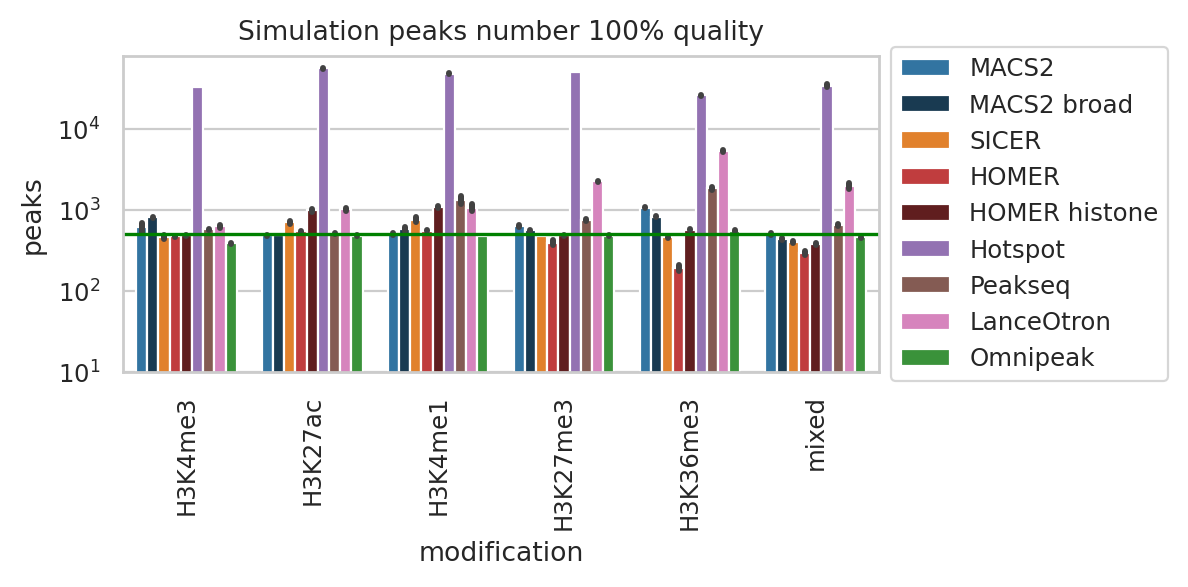

In [13]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
sns.barplot(data=df_peaks[df_peaks['quality'] == '100%'],
            x="modification", y="peaks", hue='tool', ax=ax,
            order=MODIFICATIONS_MIXED,
            hue_order=TOOLS,
            palette=TOOLS_PALETTE)
ax.xaxis.set_tick_params(rotation=90)
ax.set_title(f'Simulation peaks number 100% quality')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(10, 80_000)
ax.axhline(y=500, xmin=0, xmax=6, color='green', ls='dashed')
ax.set(yscale='log')
ax.text(0.04, 0.28, "N=500",
                transform=ax.transAxes, fontsize=6,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Overlap with ground truth peaks

In [14]:
import pyranges as pr

def load(f):
    peaks = lines(f)
    if peaks == 0:
        return pr.PyRanges(), 0, 0
    else:
        prf = pr.read_bed(f)
        return prf, peaks, prf.lengths().sum()

def compare_with_ground_truth(df):
    true_files_data = {}

    print('Loading true files...')
    for _, (m, n) in tqdm(list(df[['modification', 'n']].iterrows())):
        if (m, n) not in true_files_data:
            f = sorted_file(sampled_peaks[(m, n)])
            true_files_data[(m, n)] = load(f)

    print('Computing overlap...')
    t = []
    for _, (file, m, n) in tqdm(list(df[['file', 'modification', 'n']].iterrows())):
        true_file = sampled_peaks[(m, n)]
        true_peaks_file, true_peaks, true_length = true_files_data[(m, n)]
        peaks_file, peaks, length = load(sorted_file(file))
        true_overlap = len(true_peaks_file.overlap(peaks_file))
        overlap = len(peaks_file.overlap(true_peaks_file))
        overlap_len = true_peaks_file.intersect(peaks_file).lengths().sum()
        t.append((m, n, true_file, file, true_peaks, true_length, peaks, length, true_overlap, overlap, overlap_len))

    t = pd.DataFrame(t, columns=['m', 'n', 'true_peaks_file', 'file', 'true_peaks', 'true_length',
                                 'peaks', 'length',
                                 'true_overlap', 'overlap', 'overlap_len'])
    for c in t.columns:
        df[c] = list(t[c])
    del t

    df['Precision'] = df['overlap'] / df['peaks']
    df['Recall'] = df['true_overlap'] / df['true_peaks']
    df['F1'] = [2 / (1 / p + 1 / r) if min(p, r) > 0 else 0 for p, r in zip(df['Precision'], df['Recall'])]
    df['Jaccard'] = df['overlap_len'] / (df['true_length'] + df['length'] - df['overlap_len'])
    return df


In [15]:
df_overlap_path = f'{PATH}/overlaps.tsv'
# ! rm {df_overlap_path}
df_overlap = load_or_compute(df_overlap_path, lambda :compare_with_ground_truth(df_peaks))
df_overlap.sample(5)

Loading true files...


  0%|          | 0/2700 [00:00<?, ?it/s]

Computing overlap...


  0%|          | 0/2700 [00:00<?, ?it/s]

,file,modification,n,multiplier,tool,quality,peaks,m,true_peaks_file,true_peaks,true_length,length,true_overlap,overlap,overlap_len,Precision,Recall,F1,Jaccard
2442,/home/jetbrains/data/2025_chips/lanceotron/H3K...,H3K4me3,9,0.5,LanceOtron,50%,779,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,472271,623304,416,418,441984,0.536585,0.832,0.652409,0.676239
2206,/home/jetbrains/data/2025_chips/peakseq/H3K4me...,H3K4me1,2,0.7,Peakseq,70%,482,H3K4me1,/home/jetbrains/data/2025_chips/fastq/H3K4me1_...,500,571489,590283,455,458,539709,0.950207,0.910,0.929669,0.867611
1156,/home/jetbrains/data/2025_chips/sicer/mixed_k4...,mixed,2,0.7,SICER,70%,354,mixed,/home/jetbrains/data/2025_chips/fastq/mixed_k4...,500,2526980,2591046,358,354,2474836,1.000000,0.716,0.834499,0.936307
1510,/home/jetbrains/data/2025_chips/homer/H3K4me3_...,H3K4me3,3,1.0,HOMER histone,100%,503,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,462680,627103,393,393,425928,0.781312,0.786,0.783649,0.641598
2123,/home/jetbrains/data/2025_chips/peakseq/H3K4me...,H3K4me3,5,0.2,Peakseq,20%,304,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,482972,428809,300,303,397077,0.996711,0.600,0.749073,0.771467


# Peaks number and lengths

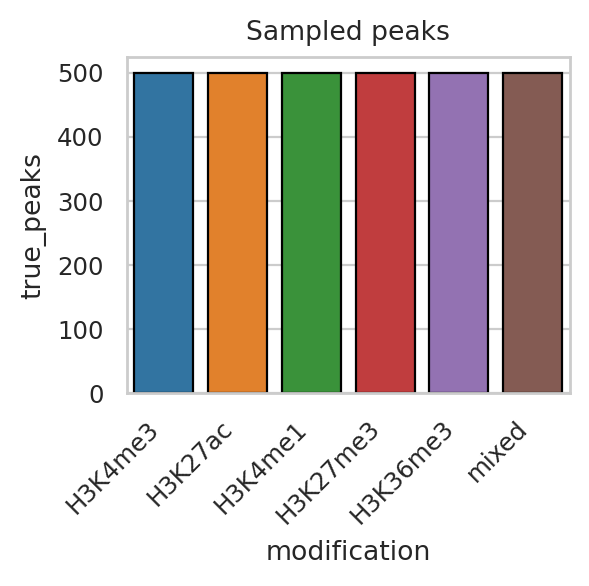

In [16]:
fig = plt.figure(figsize=(3, 3))
sns.barplot(data=df_overlap, x="modification", y="true_peaks",
            # capsize=.1, err_kws={'linewidth': 2},
            edgecolor="black",
            order=MODIFICATIONS_MIXED)
plt.xticks(rotation=45, ha='right')
plt.title('Sampled peaks')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'true_peaks_number.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [17]:
ts = []
for m, file in original_peaks.items():
    lengths = bedl(file)
    t = pd.DataFrame(dict(length=lengths))
    t = t.sample(min(len(t), 20_000))
    t['modification'] = m
    ts.append(t)
t_original = pd.concat(ts).reset_index(drop=True)
del ts
t_original

,length,modification
0,739,H3K4me3
1,1540,H3K4me3
2,1201,H3K4me3
3,197,H3K4me3
4,1570,H3K4me3
...,...,...
99995,10399,H3K36me3
99996,18399,H3K36me3
99997,5399,H3K36me3
99998,3199,H3K36me3


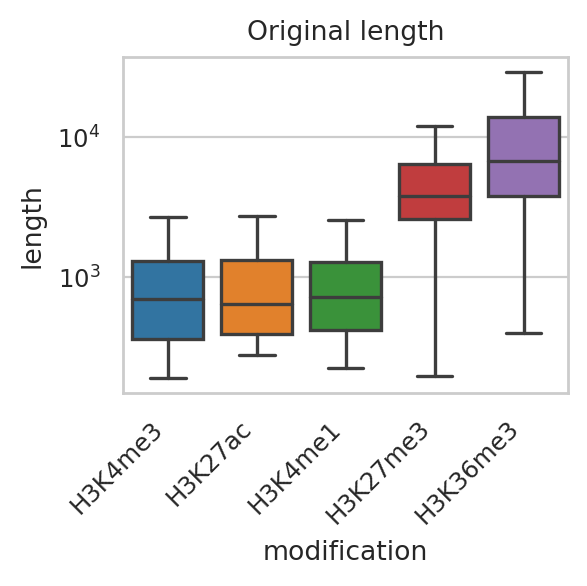

In [18]:
fig = plt.figure(figsize=(3, 3))
ax = plt.axes()
sns.boxplot(data=t_original, x="modification", y="length", showfliers=False,
            order=['H3K4me3', 'H3K27ac', 'H3K4me1', 'H3K27me3', 'H3K36me3'],
            ax=ax)
ax.set(yscale='log')
plt.xticks(rotation=45, ha='right')
plt.title('Original length')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'true_peaks_lengths.pdf'), bbox_inches='tight', dpi=300)
plt.show()

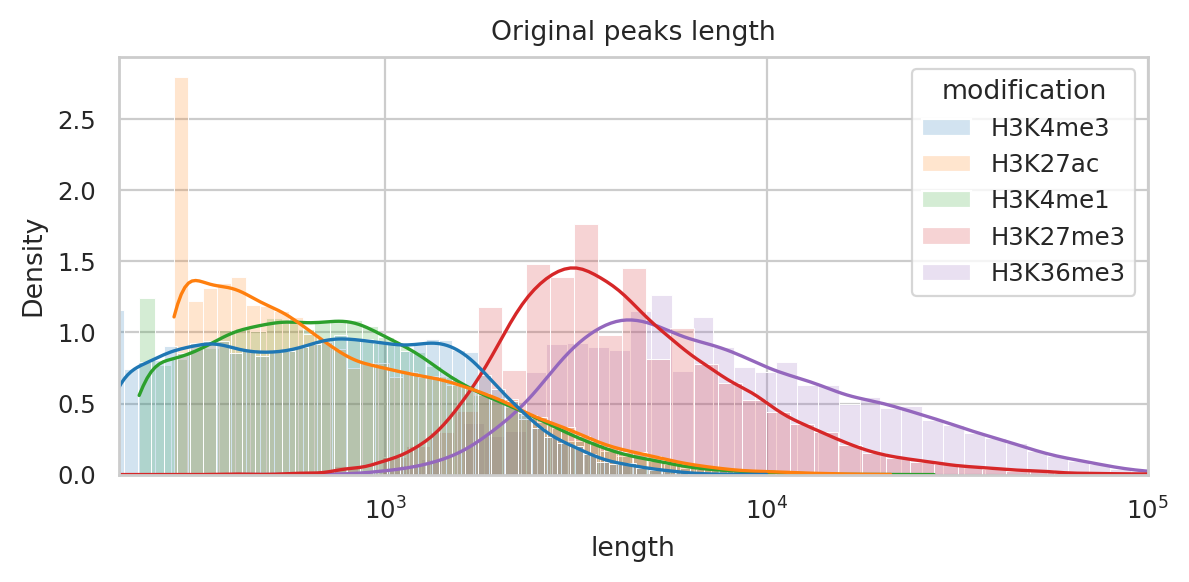

In [19]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
g_results = sns.histplot(data=t_original, x='length', hue='modification', ax=ax,
                         stat='density', common_bins=False, common_norm=False,
                         bins=50, kde=True, log_scale=True, alpha=0.2,
                         hue_order=['H3K4me3', 'H3K27ac', 'H3K4me1', 'H3K27me3', 'H3K36me3'])
g_results.set(xscale='log')
g_results.set_xlim(200, 1e5)
ax.title.set_text('Original peaks length')
plt.savefig(os.path.join(FIGURES_DIR, f'true_peaks_lengths2.pdf'), bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [20]:
ts = []
for _, (m, file) in df_overlap[['modification', 'true_peaks_file']].iterrows():
    lengths = bedl(file)
    t = pd.DataFrame(dict(length=lengths))
    t = t.sample(min(len(t), 20_000))
    t['modification'] = m
    ts.append(t)
t_true_peaks = pd.concat(ts).reset_index(drop=True)
del ts
t_true_peaks

,length,modification
0,235,H3K4me3
1,1619,H3K4me3
2,254,H3K4me3
3,2215,H3K4me3
4,893,H3K4me3
...,...,...
1349995,8999,mixed
1349996,488,mixed
1349997,304,mixed
1349998,191,mixed


/tmp/ipykernel_3259754/4091496047.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['', '1e3', '1e4', '1e5', ''])


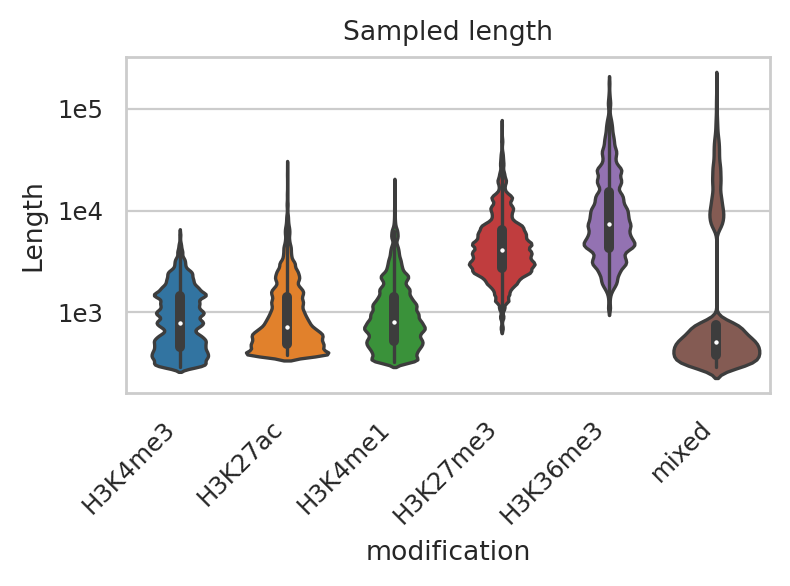

In [21]:
fig = plt.figure(figsize=(4, 3))
ax = plt.axes()
t_true_peaks['log_length'] = np.log10(t_true_peaks['length'] + 100)
sns.violinplot(data=t_true_peaks, x="modification", y="log_length",
               order=MODIFICATIONS_MIXED,
               ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_yticklabels(['', '1e3', '1e4', '1e5', ''])
plt.ylabel('Length')
plt.title('Sampled length')
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'sampled_peaks_lengths.pdf'), bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_3259754/2735551916.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['', '1e3', '1e4', '1e5', ''])


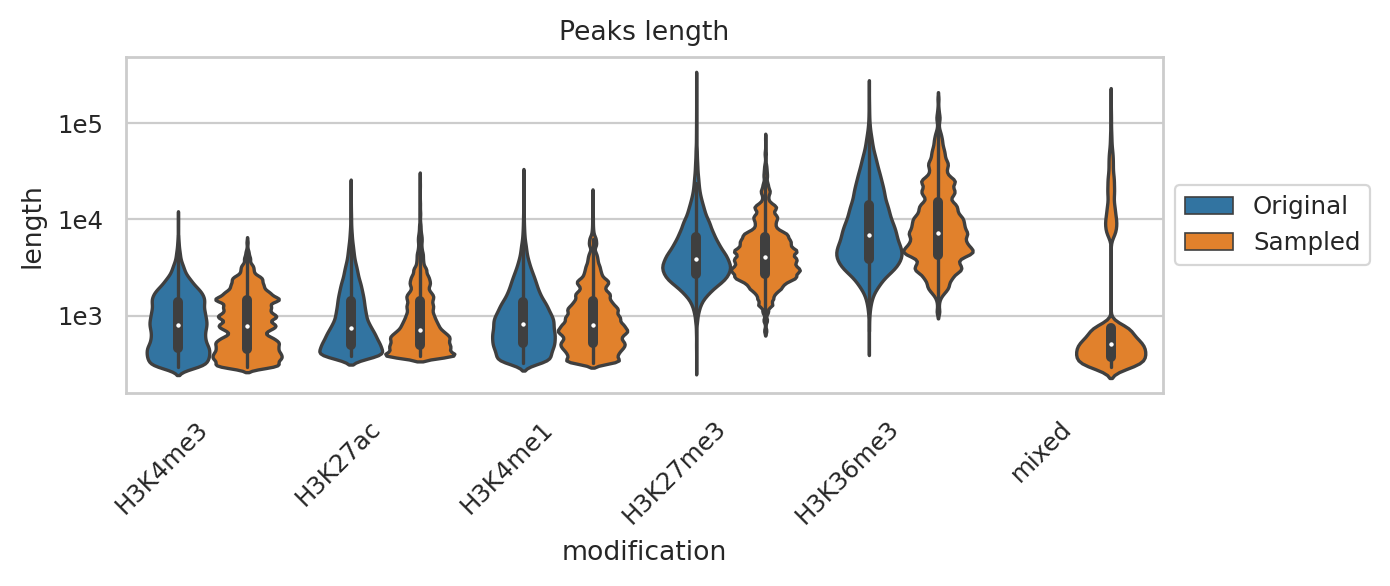

In [22]:
t_original['type'] = 'Original'
t_true_peaks['type'] = 'Sampled'
t = pd.concat([t_original, t_true_peaks]).reset_index(drop=True)
t['log_length'] = np.log10(t['length'] + 100)
plt.figure(figsize=(7, 3))
ax = plt.axes()
sns.violinplot(data=t,
               x="modification", y="log_length",
               # showfliers=False,
               hue='type', hue_order=['Original', 'Sampled'],
               order=MODIFICATIONS_MIXED,
               ax=ax)
# Put a legend to the right of the current axix
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha='right')
# ax.set(yscale='log')
ax.set_yticklabels(['', '1e3', '1e4', '1e5', ''])
plt.ylabel('length')
plt.title('Peaks length')
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'sampled_peaks_lengths.pdf'), bbox_inches='tight', dpi=300)
plt.show()

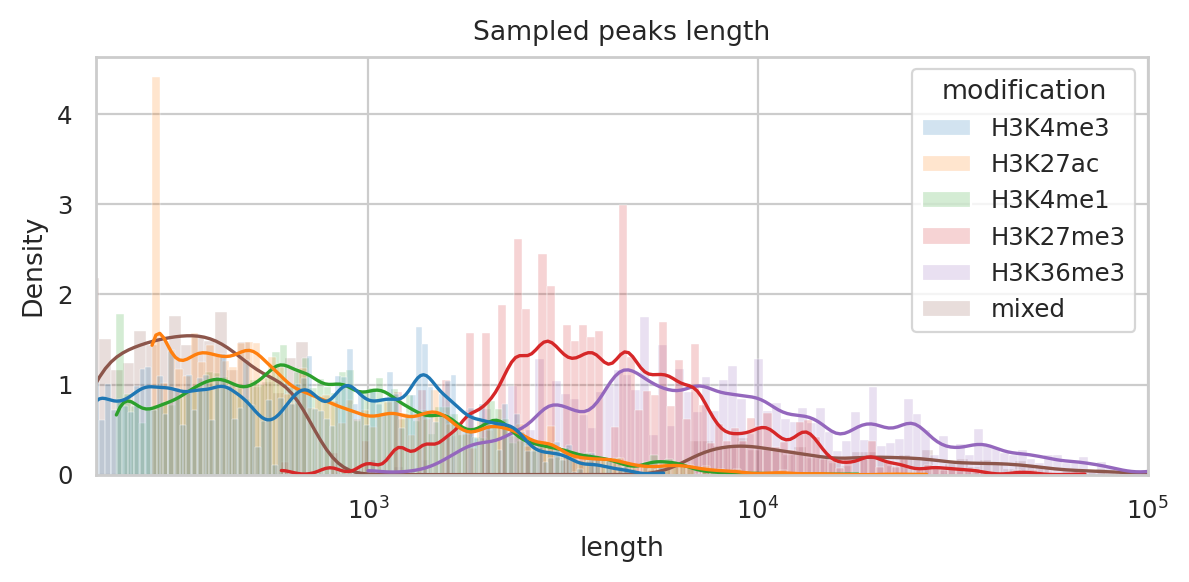

In [23]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
sns.histplot(data=t_true_peaks, x='length', hue='modification',
             stat='density', common_bins=False, common_norm=False,
             bins=100, kde=True, log_scale=True, alpha=0.2,
             hue_order=MODIFICATIONS_MIXED,
             ax=ax)
ax.set(xscale='log')
ax.set_xlim(200, 1e5)
ax.title.set_text('Sampled peaks length')
# Put a legend to the right of the current axix
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(os.path.join(FIGURES_DIR, f'sampled_peaks_lengths2.pdf'), bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

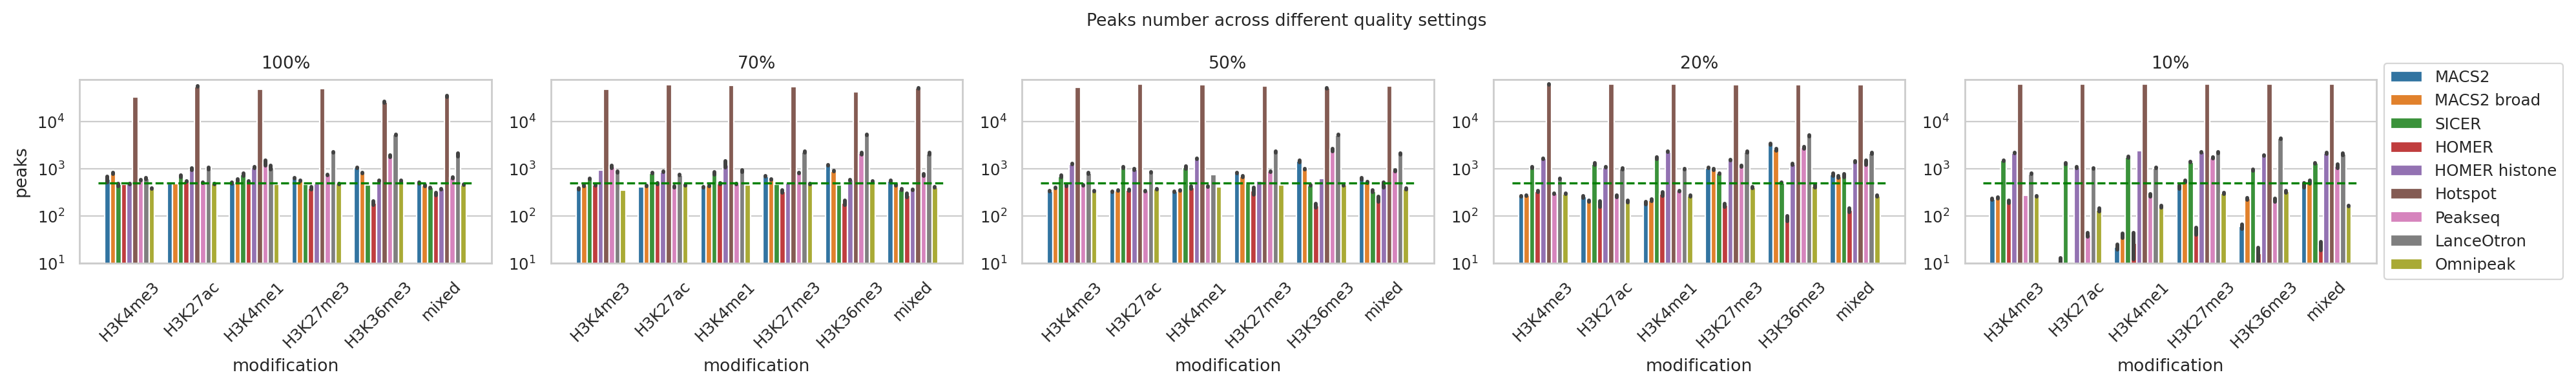

In [76]:
fig = plt.figure(figsize=(20, 3))
fig.suptitle("Peaks number across different quality settings", fontsize="large")
axs = [plt.subplot(1, 5, i + 1) for i in range(5)]
for i, q in enumerate(df_peaks['quality'].unique()):
    ax = axs[i]
    sns.barplot(data=df_peaks[df_peaks['quality'] == q], x="modification", y="peaks", hue='tool', ax=ax,
                order=MODIFICATIONS_MIXED,
                hue_order=TOOLS)
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_title(f'{q}')
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
    ax.set(yscale='log')
    ax.set_ylim(bottom=10, top=80_000)
    ax.hlines(y = 500, xmin = -0.5, xmax = 5.5, color = 'green', linestyle = 'dashed')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

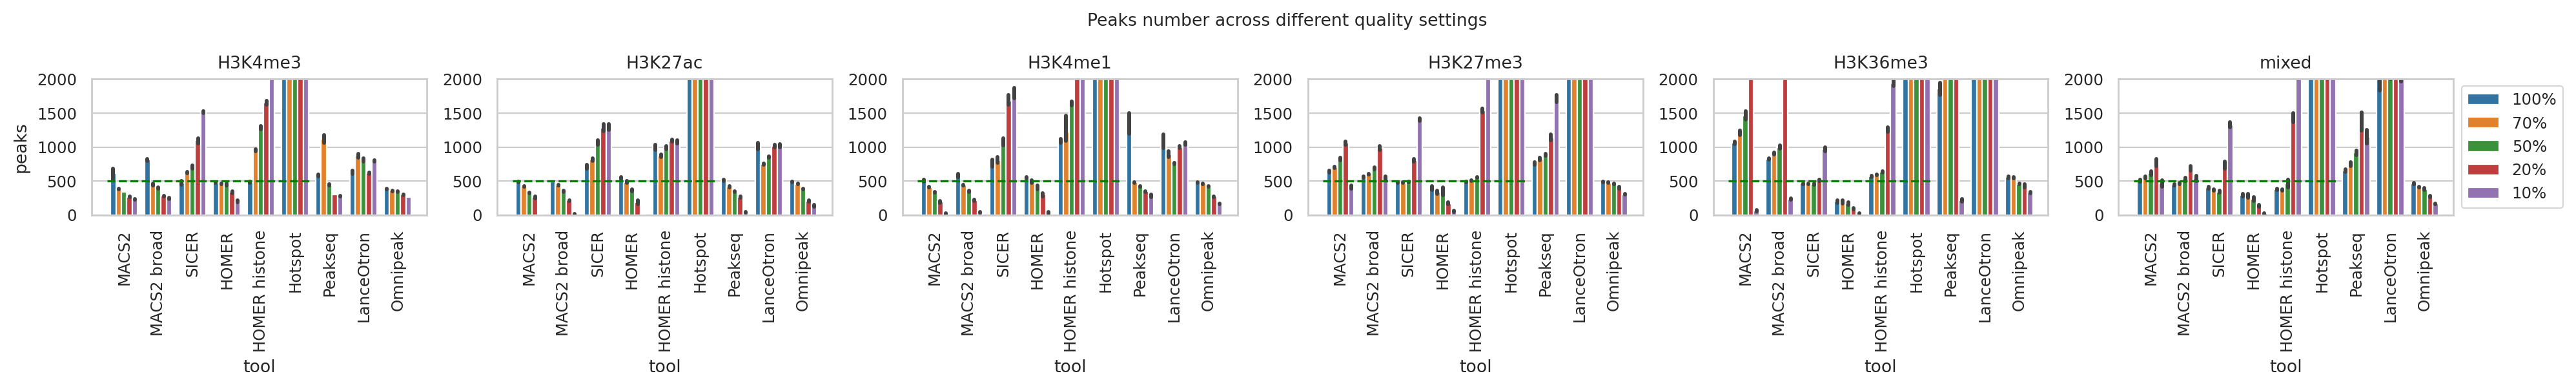

In [77]:
fig = plt.figure(figsize=(20, 3))
fig.suptitle("Peaks number across different quality settings", fontsize="large")
axs = [plt.subplot(1, 6, i + 1) for i in range(6)]
for i, m in enumerate(MODIFICATIONS_MIXED):
    ax = axs[i]
    sns.barplot(data=df_peaks[df_peaks['modification'] == m], x="tool", y="peaks", hue='quality', ax=ax,
                hue_order=['100%', '70%', '50%', '20%', '10%'],
                order=TOOLS)
    ax.xaxis.set_tick_params(rotation=90)
    ax.set_title(f'{m}')
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
    ax.set_ylim(0, 2_000)
    ax.hlines(y = 500, xmin = -0.5, xmax = 5.5, color = 'green', linestyle = 'dashed')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

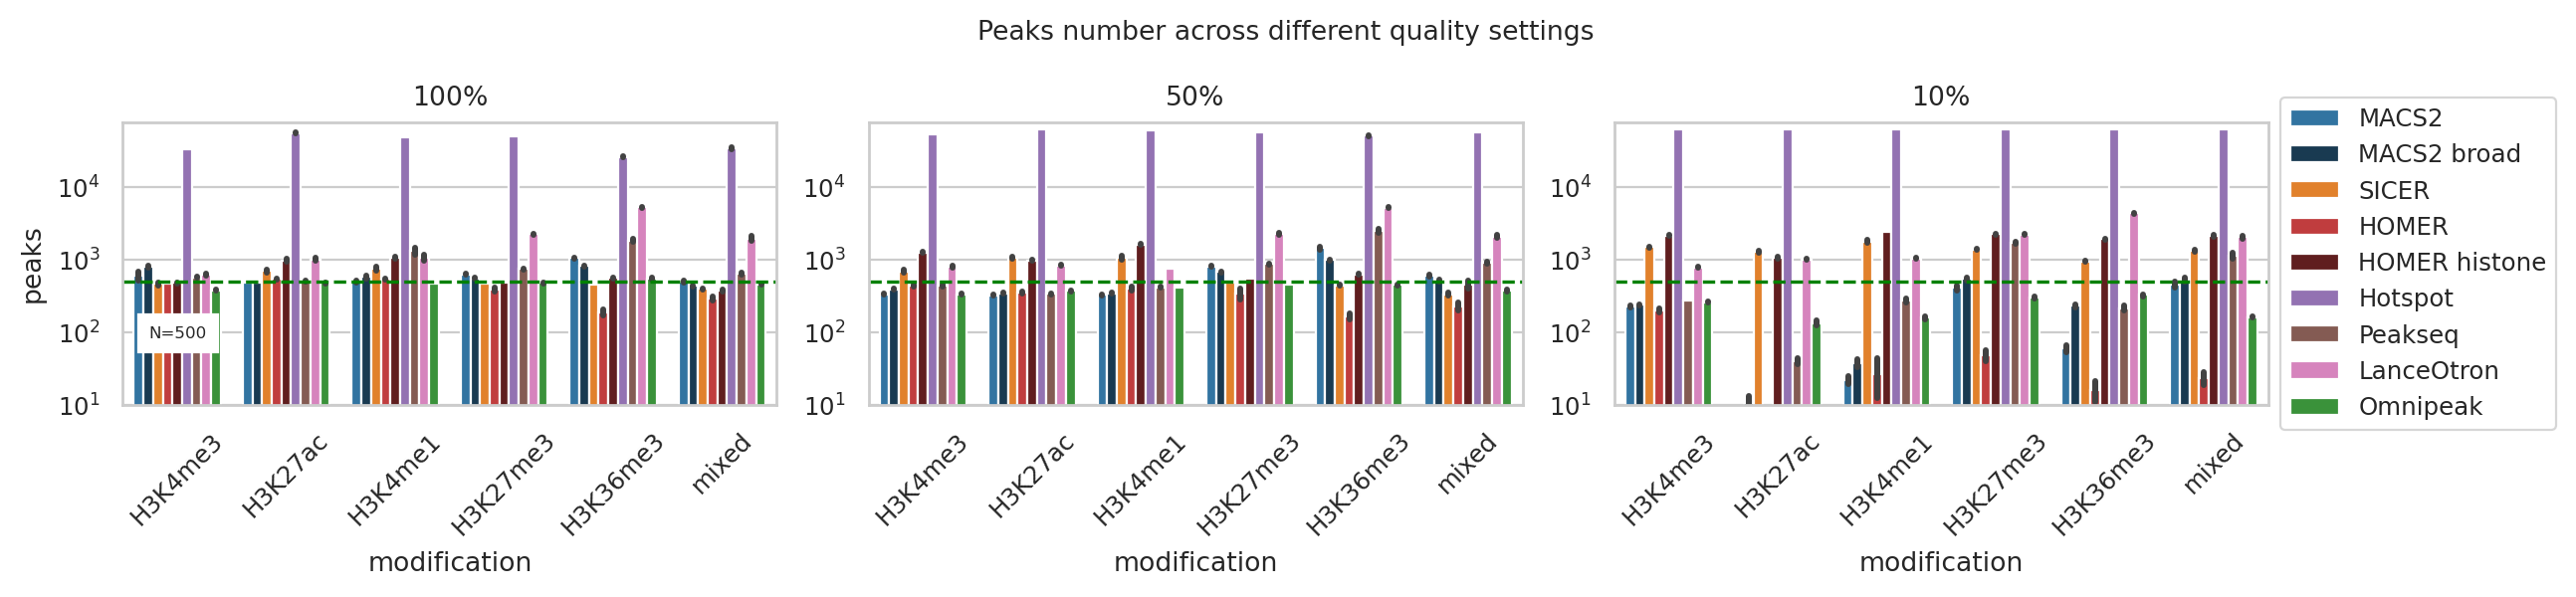

In [26]:
fig = plt.figure(figsize=(13, 3))
fig.suptitle("Peaks number across different quality settings", fontsize="large")
axs = [plt.subplot(1, 3, i + 1) for i in range(3)]
for i, q in enumerate(['100%', '50%', '10%']):
    ax = axs[i]
    sns.barplot(data=df_peaks[df_peaks['quality'] == q], x="modification", y="peaks", hue='tool', ax=ax,
                order=MODIFICATIONS_MIXED,
                palette=TOOLS_PALETTE,
                hue_order=TOOLS)
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_title(f'{q}')
    if i == 0:
        ax.text(0.04, 0.28, "N=500",
                transform=ax.transAxes, fontsize=6,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
    ax.set_ylim(10, 80_000)
    ax.axhline(y=500, xmin=0, xmax=6, color='green', ls='dashed')
    ax.set(yscale='log')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

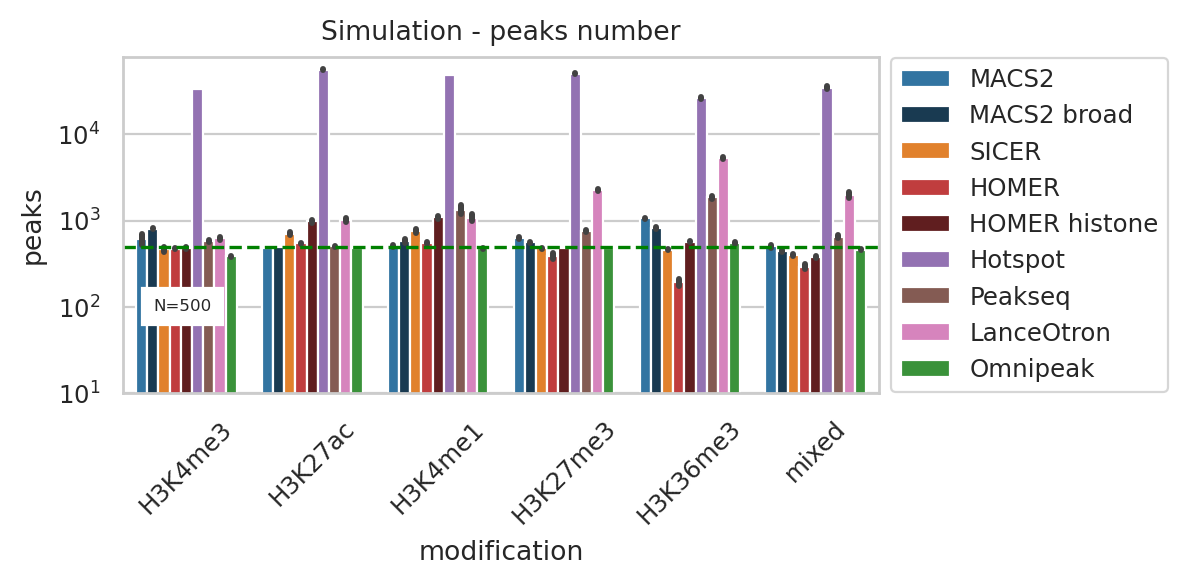

In [73]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
sns.barplot(data=df_peaks[df_peaks['quality'] == '100%'], x="modification", y="peaks", hue='tool', ax=ax,
            order=MODIFICATIONS_MIXED,
            hue_order=TOOLS,
            palette=TOOLS_PALETTE)
ax.xaxis.set_tick_params(rotation=45)
ax.set_title('Simulation - peaks number')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(10, 80_000)
ax.set(yscale='log')
ax.axhline(y=500, xmin=0, xmax=6, color='green', ls='dashed')
ax.text(0.04, 0.28, "N=500",
        transform=ax.transAxes, fontsize=6,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Lengths

In [28]:
def load_lens(df):
    ts = []
    for _, (m, q, tool, file) in df[['modification', 'quality', 'tool', 'file']].iterrows():
        lengths = bedl(file)
        t = pd.DataFrame(dict(length=lengths))
        t = t.sample(min(len(t), 20_000))
        t['modification'] = m
        t['quality'] = q
        t['tool'] = tool
        ts.append(t)
    t = pd.concat(ts).reset_index(drop=True)
    del ts
    return t

In [29]:
df_lens = load_lens(df_peaks)
df_lens.sample(5)

,length,modification,quality,tool
113795,1892.0,H3K36me3,70%,MACS2
747582,302.0,H3K27ac,100%,HOMER
7101055,635.0,mixed,50%,Hotspot
5658807,397.0,H3K36me3,100%,Hotspot
4457759,788.0,H3K27me3,100%,Hotspot


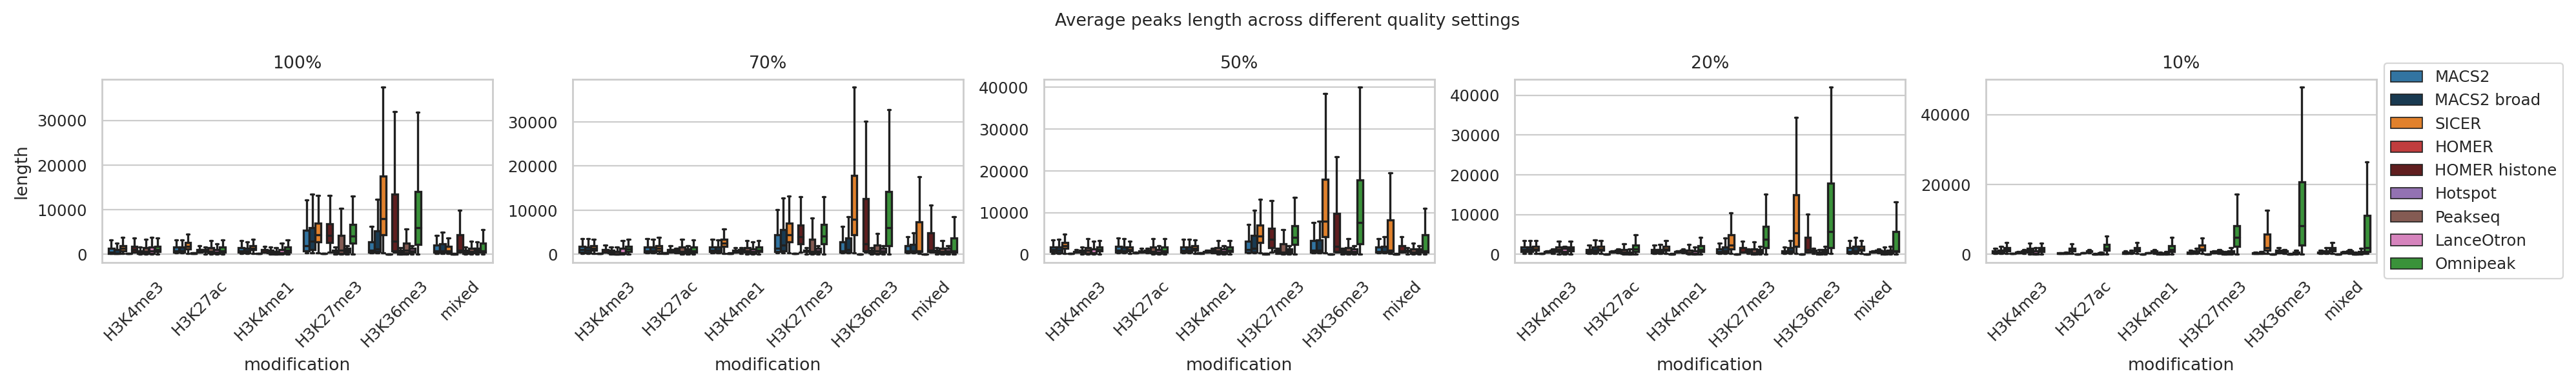

In [30]:
fig = plt.figure(figsize=(20, 3))
fig.suptitle("Average peaks length across different quality settings", fontsize="large")
axs = [plt.subplot(1, 5, i + 1) for i in range(5)]
for i, q in enumerate(df_peaks['quality'].unique()):
    ax = axs[i]
    sns.boxplot(data=df_lens[df_lens['quality']==q], x="modification", y="length", hue='tool', showfliers=False, ax=ax,
                order=MODIFICATIONS_MIXED,
                palette=TOOLS_PALETTE,
                hue_order=TOOLS)
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_title(f'{q}')
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'lengths.pdf'), bbox_inches='tight', dpi=300)
plt.show()

100%
50%
10%


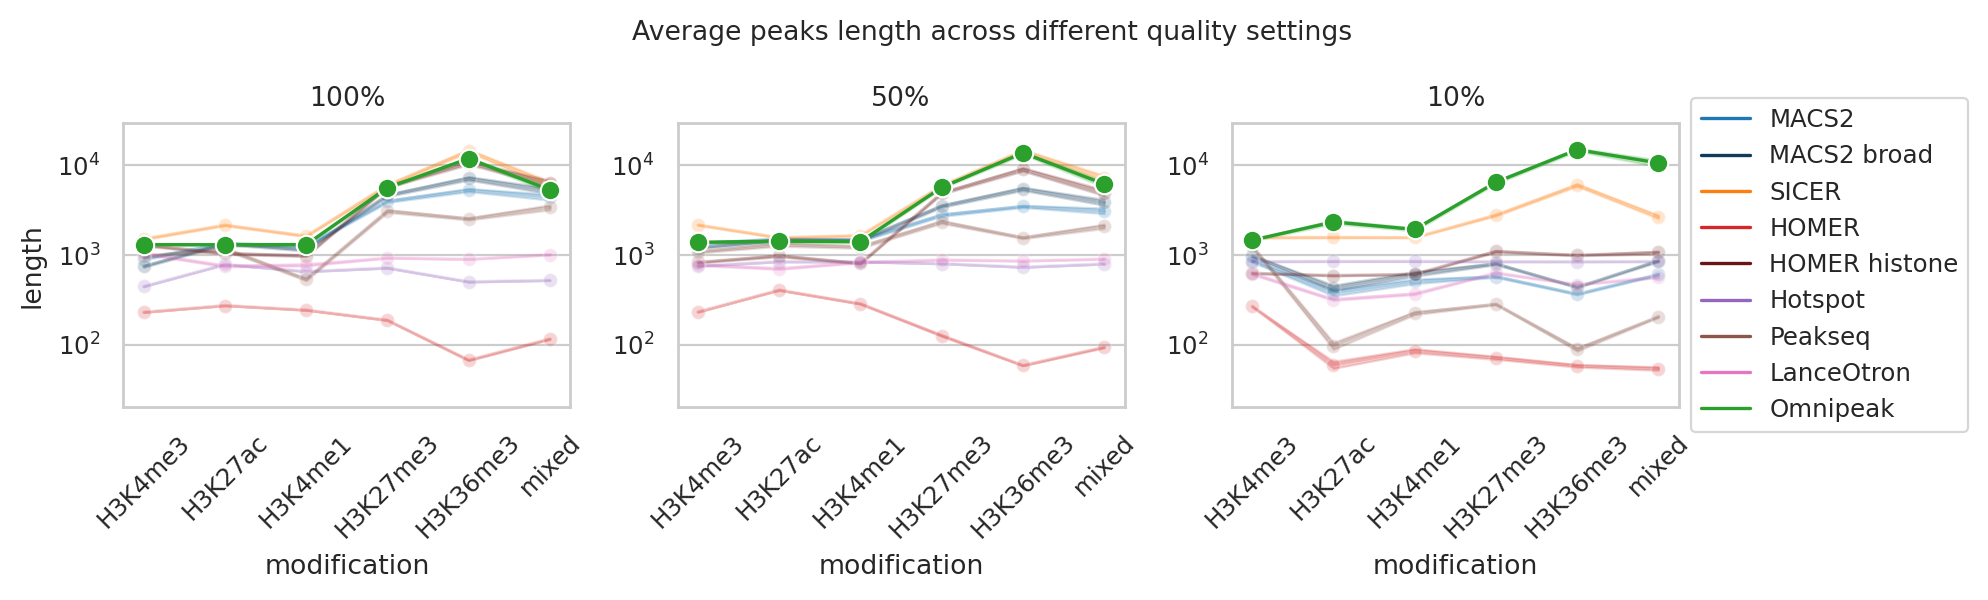

In [31]:
fig = plt.figure(figsize=(10, 3))
fig.suptitle("Average peaks length across different quality settings", fontsize="large")
axs = [plt.subplot(1, 3, i + 1) for i in range(3)]
for i, q in enumerate(['100%', '50%', '10%']):
    ax = axs[i]
    print(q)
    t = df_lens[df_lens['quality'] == q].copy()
    t['mindex'] = 0
    for j, m in enumerate(MODIFICATIONS_MIXED):
        t.loc[t['modification'] == m, 'mindex'] = j
    t = t.sort_values(by=['mindex', 'tool', 'length'])
    sns.lineplot(data=t[t['tool'] != 'Omnipeak'],
             y='length', x='mindex', hue='tool', orient='x',
             alpha=0.2,
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             marker='o', markersize=5,
             legend=False,
             ax=ax)
    sns.lineplot(data=t[t['tool'] == 'Omnipeak'],
             y='length', x='mindex', hue='tool', orient='x',
             alpha=1.0,
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             marker='o', markersize=7,
             legend=True,
             ax=ax)
    ax.set_xticks(range(6), minor=False)
    ax.set_xticklabels(MODIFICATIONS_MIXED)
    ax.set_xlabel('modification')
    ax.set_ylabel('length')
    ax.set(yscale='log')
    ax.set_ylim(20, 3e4)
    ax.title.set_text(f'{q}')
    ax.xaxis.set_tick_params(rotation=45)
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
    # Hide grid lines
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

# Jaccard, precision, recall, F1

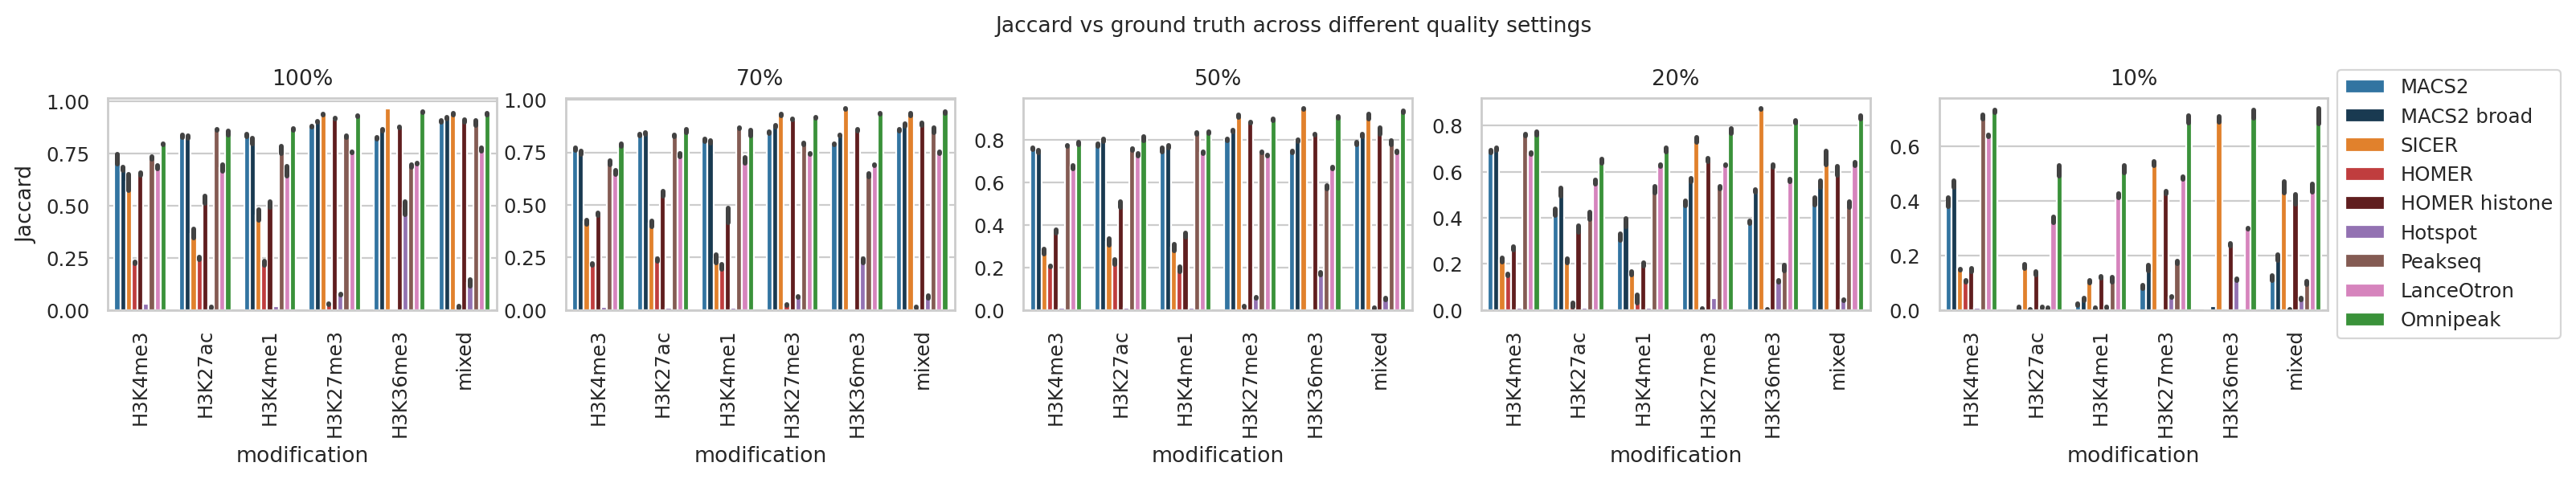

In [32]:
fig = plt.figure(figsize=(16, 3))
fig.suptitle("Jaccard vs ground truth across different quality settings", fontsize="large")
axs = [plt.subplot(1, 5, i + 1) for i in range(5)]
for i, q in enumerate(df_peaks['quality'].unique()):
    ax = axs[i]
    sns.barplot(data=df_peaks[df_peaks['quality'] == q], x="modification", y="Jaccard", hue='tool', ax=ax,
                order=MODIFICATIONS_MIXED,
                palette=TOOLS_PALETTE,
                hue_order=TOOLS)
    ax.xaxis.set_tick_params(rotation=90)
    ax.set_title(f'{q}')
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'jaccard.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [33]:
df_peaks0 = df_peaks.copy()
# Add 0.0 multiplier
for m, tool in product(MODIFICATIONS_MIXED, TOOLS):
    row = [None, m, None, 0.0, tool, '0%'] + [None] * (len(df_peaks.columns) - 7) + [0.0]
    df_peaks0.loc[len(df_peaks0)] = row
df_peaks0

,file,modification,n,multiplier,tool,quality,peaks,m,true_peaks_file,true_peaks,true_length,length,true_overlap,overlap,overlap_len,Precision,Recall,F1,Jaccard
0,/home/jetbrains/data/2025_chips/macs2/H3K4me3_...,H3K4me3,1,1.0,MACS2,100%,420,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,470443,517810,381,384,429552,0.914286,0.762,0.831225,0.768841
1,/home/jetbrains/data/2025_chips/macs2/H3K4me3_...,H3K4me3,1,0.7,MACS2,70%,362,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,470443,475693,345,348,413007,0.961326,0.69,0.803372,0.774685
2,/home/jetbrains/data/2025_chips/macs2/H3K4me3_...,H3K4me3,1,0.5,MACS2,50%,349,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,470443,458037,318,324,399362,0.928367,0.636,0.754863,0.754769
3,/home/jetbrains/data/2025_chips/macs2/H3K4me3_...,H3K4me3,1,0.2,MACS2,20%,264,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,470443,384722,253,258,352923,0.977273,0.506,0.666769,0.702695
4,/home/jetbrains/data/2025_chips/macs2/H3K4me3_...,H3K4me3,1,0.1,MACS2,10%,240,H3K4me3,/home/jetbrains/data/2025_chips/fastq/H3K4me3_...,500,470443,211309,179,238,204095,0.991667,0.358,0.526081,0.427284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2749,None,mixed,None,0.0,HOMER histone,0%,None,None,None,None,None,None,None,None,None,None,None,None,0.000000
2750,None,mixed,None,0.0,Hotspot,0%,None,None,None,None,None,None,None,None,None,None,None,None,0.000000
2751,None,mixed,None,0.0,Peakseq,0%,None,None,None,None,None,None,None,None,None,None,None,None,0.000000
2752,None,mixed,None,0.0,LanceOtron,0%,None,None,None,None,None,None,None,None,None,None,None,None,0.000000


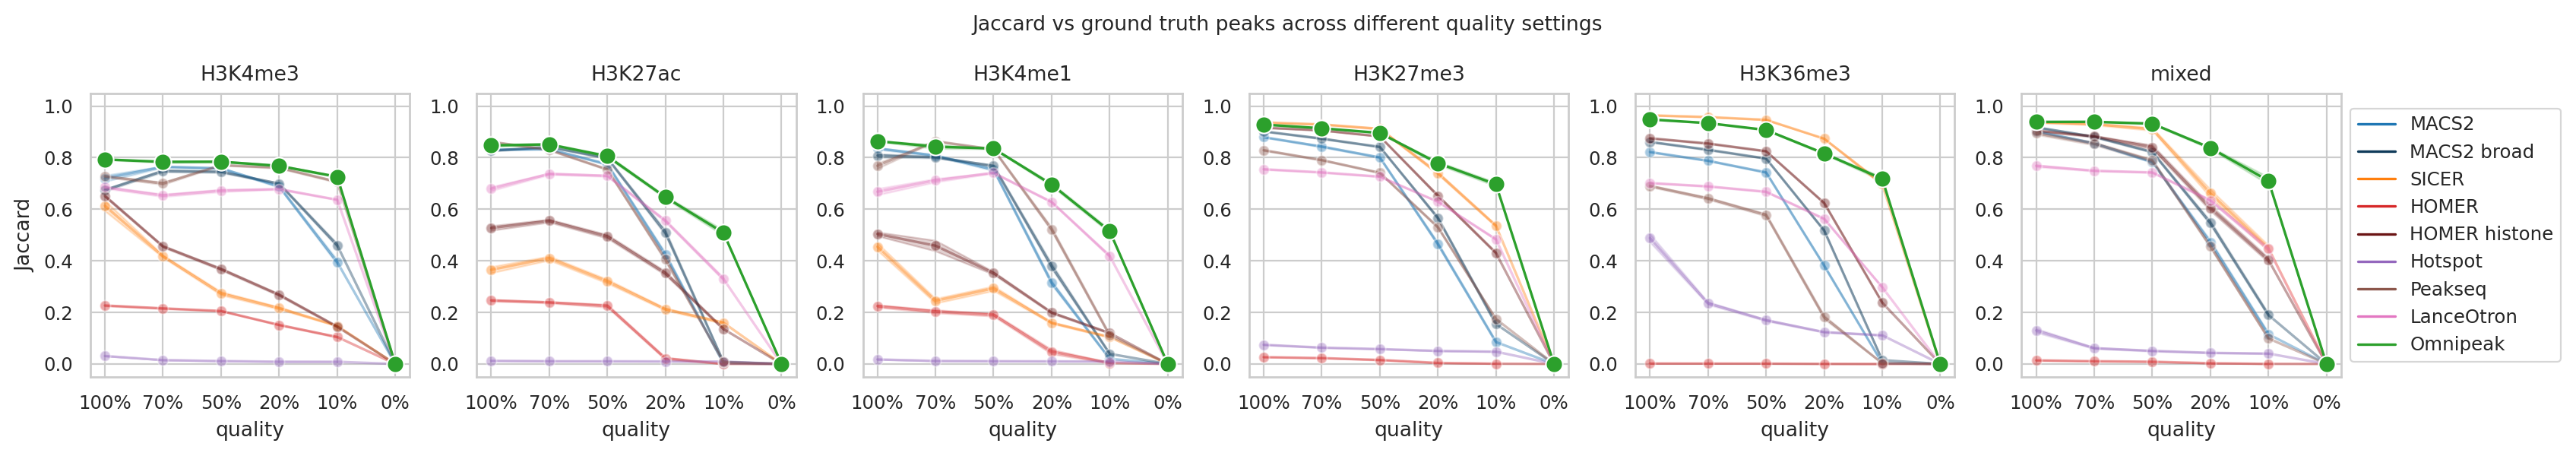

In [34]:
fig = plt.figure(figsize=(17, 3))
fig.suptitle("Jaccard vs ground truth peaks across different quality settings", fontsize="large")
axs = [plt.subplot(1, 6, i + 1) for i in range(6)]
for i, m in enumerate(MODIFICATIONS_MIXED):
    ax = axs[i]
    sns.lineplot(data=df_peaks0[(df_peaks0['modification'] == m) &
                                (df_peaks0['tool'] != 'Omnipeak')], x="quality", y="Jaccard", hue='tool', ax=ax,
                 hue_order=TOOLS,
                 palette=TOOLS_PALETTE,
                 errorbar='se',
                 alpha=0.4,
                 marker='o', markersize=5)
    sns.lineplot(data=df_peaks0[(df_peaks0['modification'] == m) &
                                (df_peaks0['tool'] == 'Omnipeak')], x="quality", y="Jaccard", hue='tool', ax=ax,
                 hue_order=TOOLS,
                 palette=TOOLS_PALETTE,
                 errorbar='se',
                 marker='o', markersize=8,
                 legend=False)
    ax.set_title(f'{m}')
    ax.set_ylim([-0.05, 1.05])
    # Put a legend to the right of the current axis
    if i == 5:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'jaccard2.pdf'), bbox_inches='tight', dpi=300)
plt.show()

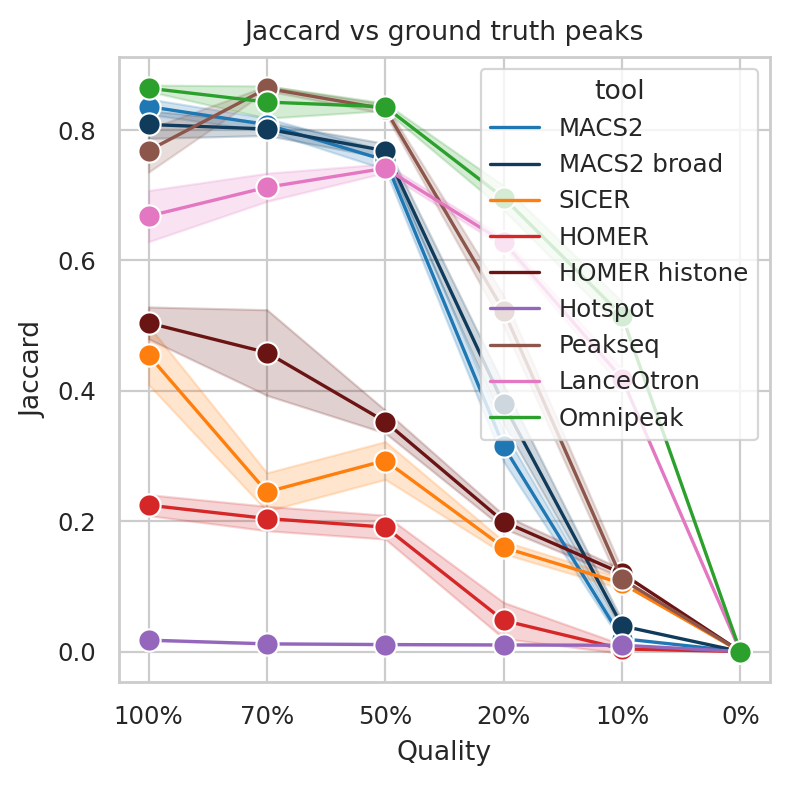

In [35]:
plt.figure(figsize=(4, 4))
sns.lineplot(data=df_peaks0[df_peaks0['modification'] == 'H3K4me1'], x="quality", y="Jaccard", hue='tool',
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             errorbar='sd', marker='o', markersize=8)
plt.title('Jaccard vs ground truth peaks')
plt.xlabel('Quality')
plt.ylabel('Jaccard')
plt.tight_layout()
plt.show()

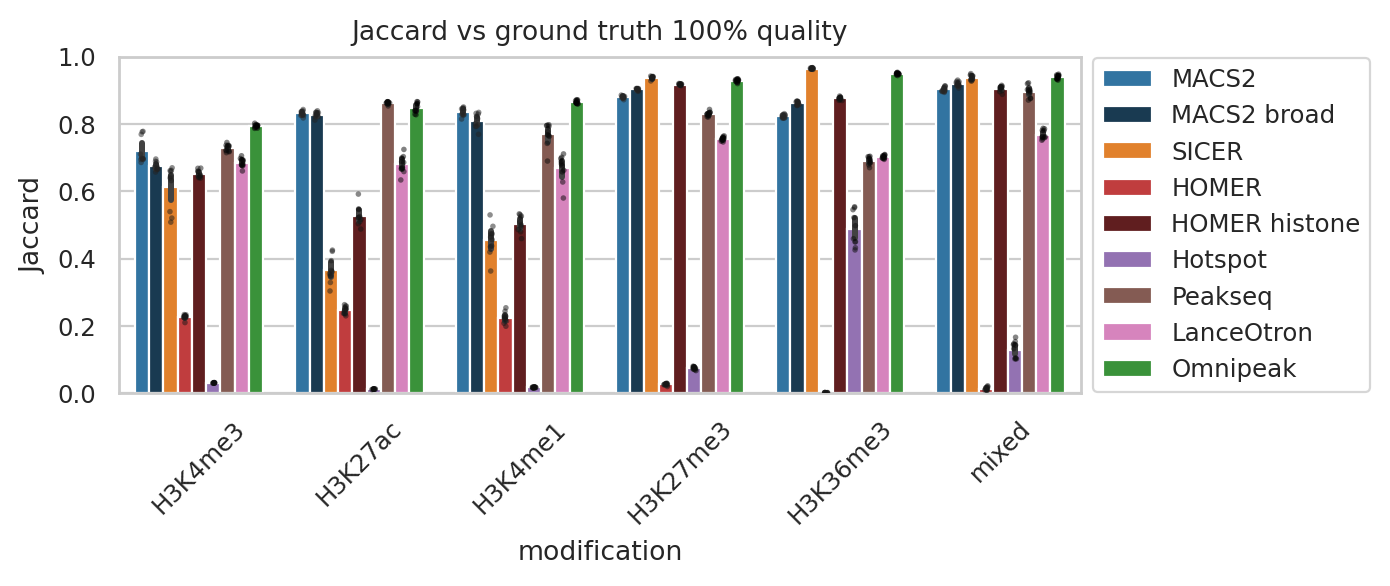

In [75]:
plt.figure(figsize=(7, 3))
ax = plt.axes()
t = df_peaks[df_peaks['quality'] == '100%']
sns.barplot(data=t,
            x='modification', y='Jaccard', hue='tool',
            hue_order=TOOLS,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t,
              x='modification', y='Jaccard', hue='tool',
              dodge=True, size=2, color="black", alpha=0.5, palette='dark:black',
              hue_order=TOOLS,
              legend=False,
              ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Jaccard vs ground truth 100% quality')
ax.xaxis.set_tick_params(rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'jaccard3.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Jaccard AUC vs quality

In [37]:
t = []
for (m, n, tool), dft in tqdm(list(df_peaks0[df_peaks0['quality'] != '0%'].groupby(['modification', 'n', 'tool']))):
    aj = 0
    mprev = 0
    jprev = 0
    for _, row in dft.sort_values(by=['multiplier']).iterrows():
        aj += (row['multiplier'] - mprev) * (row['Jaccard'] + jprev) / 2
        mprev, jprev = row['multiplier'], row['Jaccard']
    t.append((m, n, tool, aj))
dfjaccardauc = pd.DataFrame(data=t, columns=['modification', 'n', 'tool', 'AUC'])
dfjaccardauc.sample(3)

  0%|          | 0/540 [00:00<?, ?it/s]

,modification,n,tool,AUC
318,H3K4me1,6,LanceOtron,0.626969
2,H3K27ac,1,Hotspot,0.009635
153,H3K27me3,8,HOMER,0.015956


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

H3K36me3_LanceOtron vs. H3K36me3_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
mixed_LanceOtron vs. mixed_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K4me3_LanceOtron vs. H3K4me3_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K27ac_LanceOtron vs. H3K27ac_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K4me1_LanceOtron vs. H3K4me1_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K27me3_LanceOtron vs. H3K27me3_Omnipeak: Mann-Whitney-Wilcoxon test two-s

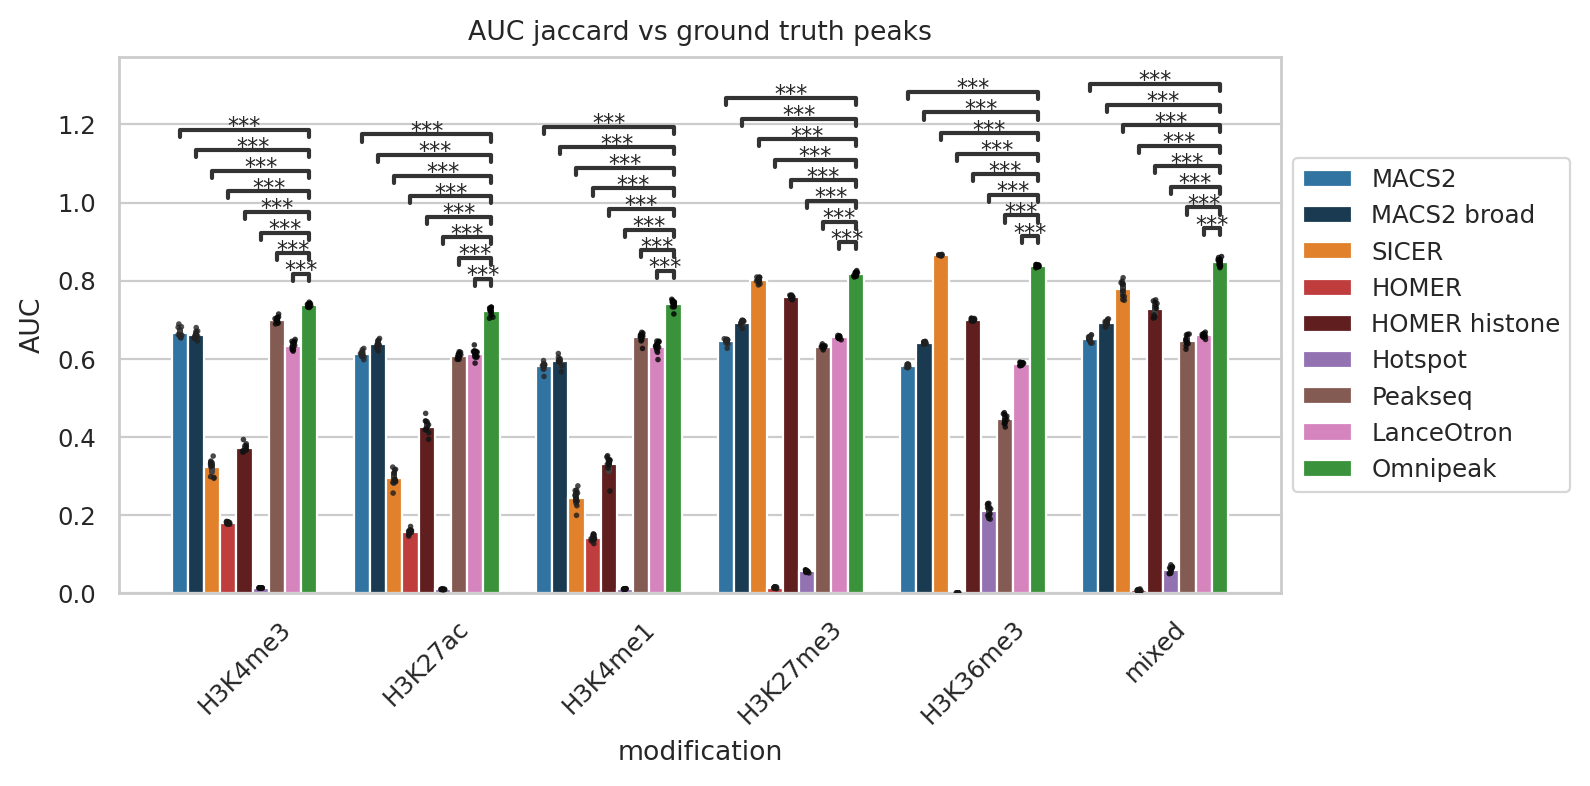

In [38]:
plt.figure(figsize=(8, 4))
ax = plt.axes()
ax.title.set_text('AUC jaccard vs ground truth peaks')
sns.barplot(data=dfjaccardauc, x='modification', y='AUC', hue='tool',
            # capsize=.05, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=MODIFICATIONS_MIXED,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=dfjaccardauc, x='modification', y='AUC', hue='tool',
              dodge=True, size=2, color="black", alpha=0.8, palette='dark:black',
              order=MODIFICATIONS_MIXED,
              hue_order=TOOLS, legend=False,
              ax=ax)
ax.xaxis.set_tick_params(rotation=45)
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

pairs = [((m, tl), (m, 'Omnipeak')) for m, tl in
         product(MODIFICATIONS_MIXED, [tool for tool in TOOLS if tool != 'Omnipeak'])]  # which groups to compare
annot = Annotator(ax, pairs, data=dfjaccardauc, x='modification', y='AUC', hue='tool',
                  order=MODIFICATIONS_MIXED, hue_order=TOOLS)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'jaccard_auc2.pdf'), bbox_inches='tight', dpi=300)
plt.show()

Precision


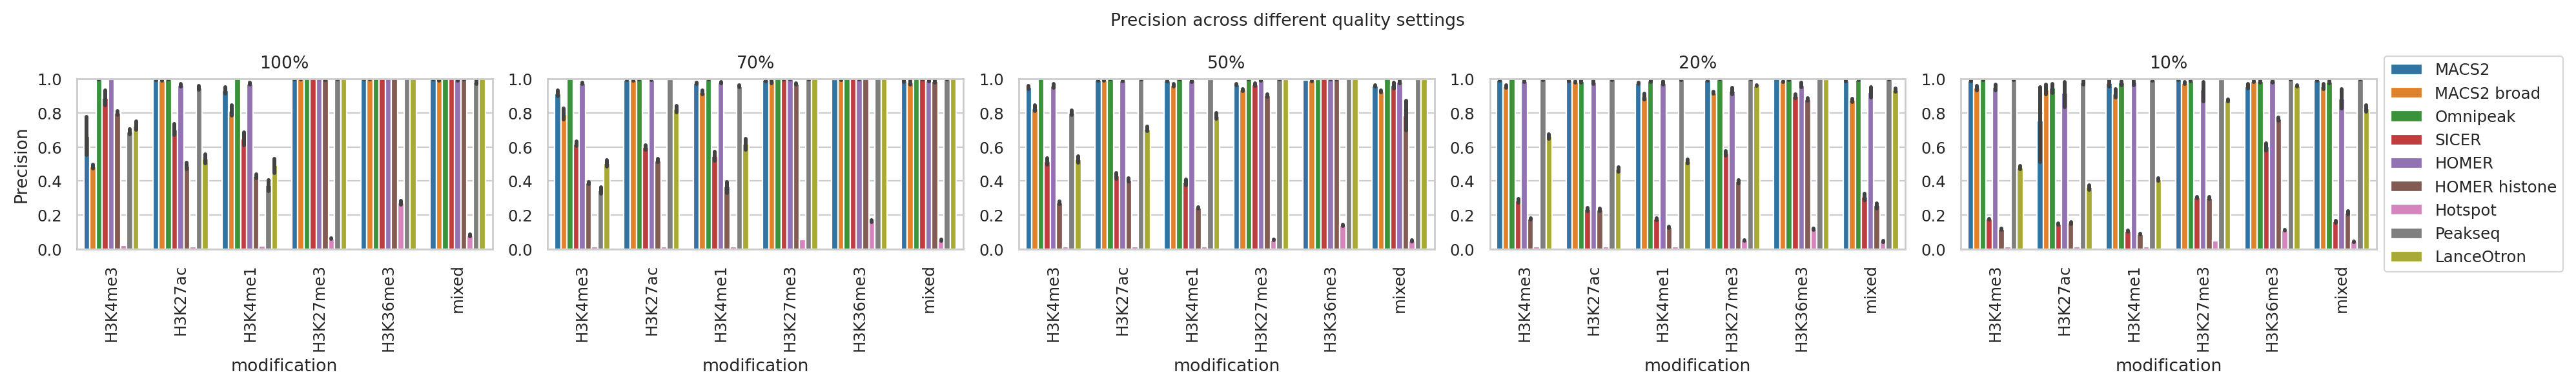

Recall


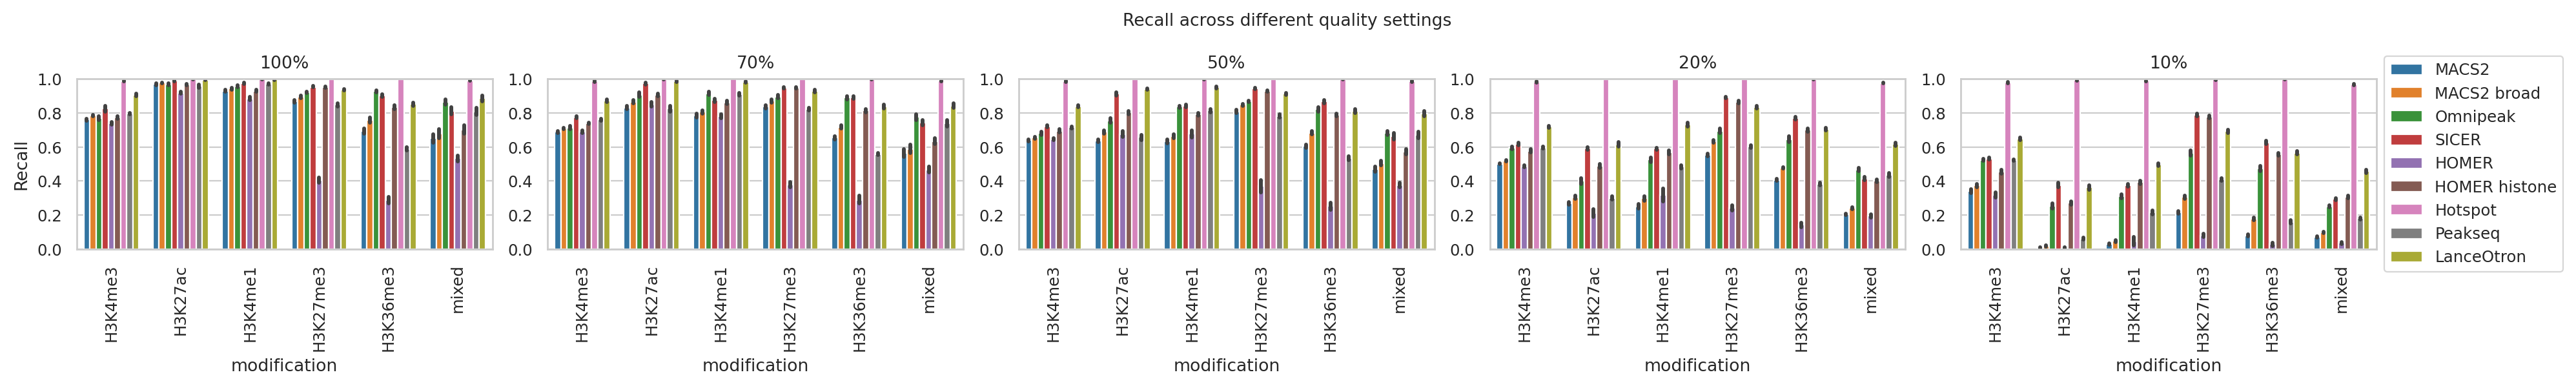

F1


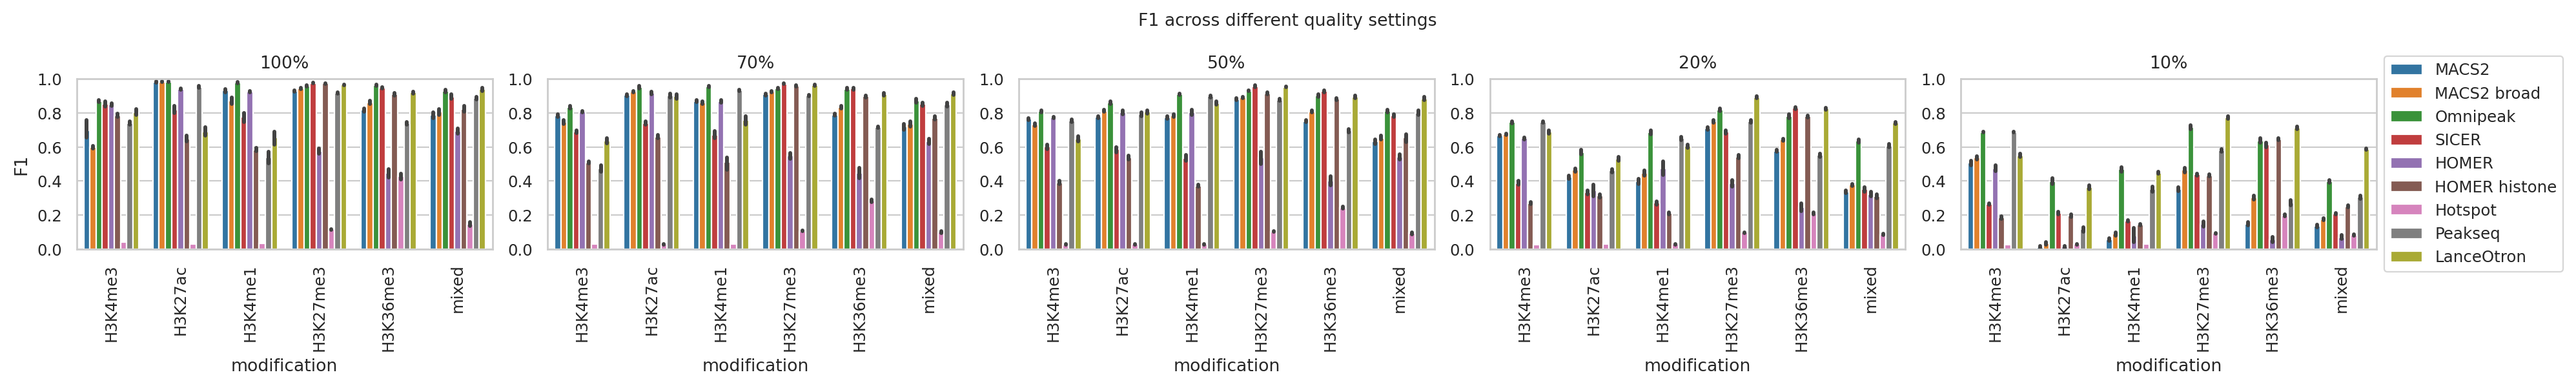

In [39]:
for y in ['Precision', 'Recall', 'F1']:
    print(y)
    fig = plt.figure(figsize=(20, 3))
    fig.suptitle(f"{y} across different quality settings", fontsize="large")
    axs = [plt.subplot(1, 5, i + 1) for i in range(5)]
    for i, q in enumerate(df_peaks['quality'].unique()):
        if q == '0%':
            continue
        ax = axs[i]
        sns.barplot(data=df_peaks[(df_peaks['quality'] == q)], x="modification", y=y, hue='tool', ax=ax,
                    order=MODIFICATIONS_MIXED)
        ax.xaxis.set_tick_params(rotation=90)
        ax.set_title(f'{q}')
        # Put a legend to the right of the current axis
        if i == len(axs) - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        else:
            ax.legend().set_visible(False)
        if i > 0:
            ax.set_ylabel(None)
        ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'{y}.pdf'), bbox_inches='tight', dpi=300)
    plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

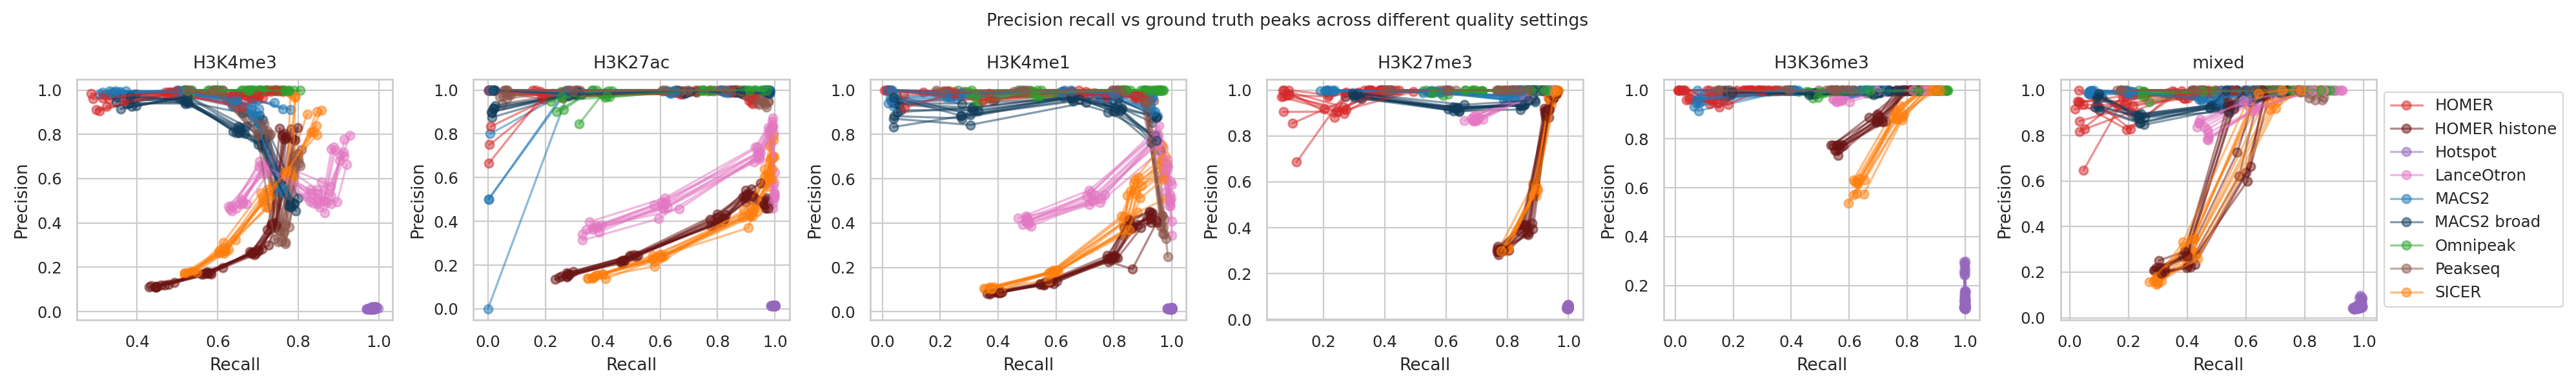

In [40]:
fig = plt.figure(figsize=(20, 3))
fig.suptitle("Precision recall vs ground truth peaks across different quality settings", fontsize="large")
axs = [plt.subplot(1, 6, i + 1) for i in range(6)]
labels = []  # Hack to add labels only once
for i, m in enumerate(tqdm(MODIFICATIONS_MIXED)):
    ax = axs[i]
    for (n, tool), dft in df_peaks[df_peaks['modification'] == m].groupby(['n', 'tool']):
        if m == 'mixed' and tool not in labels:
            ax.plot(dft['Recall'], dft['Precision'], marker='o', label=tool, color=TOOLS_PALETTE[tool], alpha=0.5)
            labels.append(tool)
        else:
            ax.plot(dft['Recall'], dft['Precision'], marker='o', color=TOOLS_PALETTE[tool], alpha=0.5)
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'{m}')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'auc.pdf'), bbox_inches='tight', dpi=300)
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

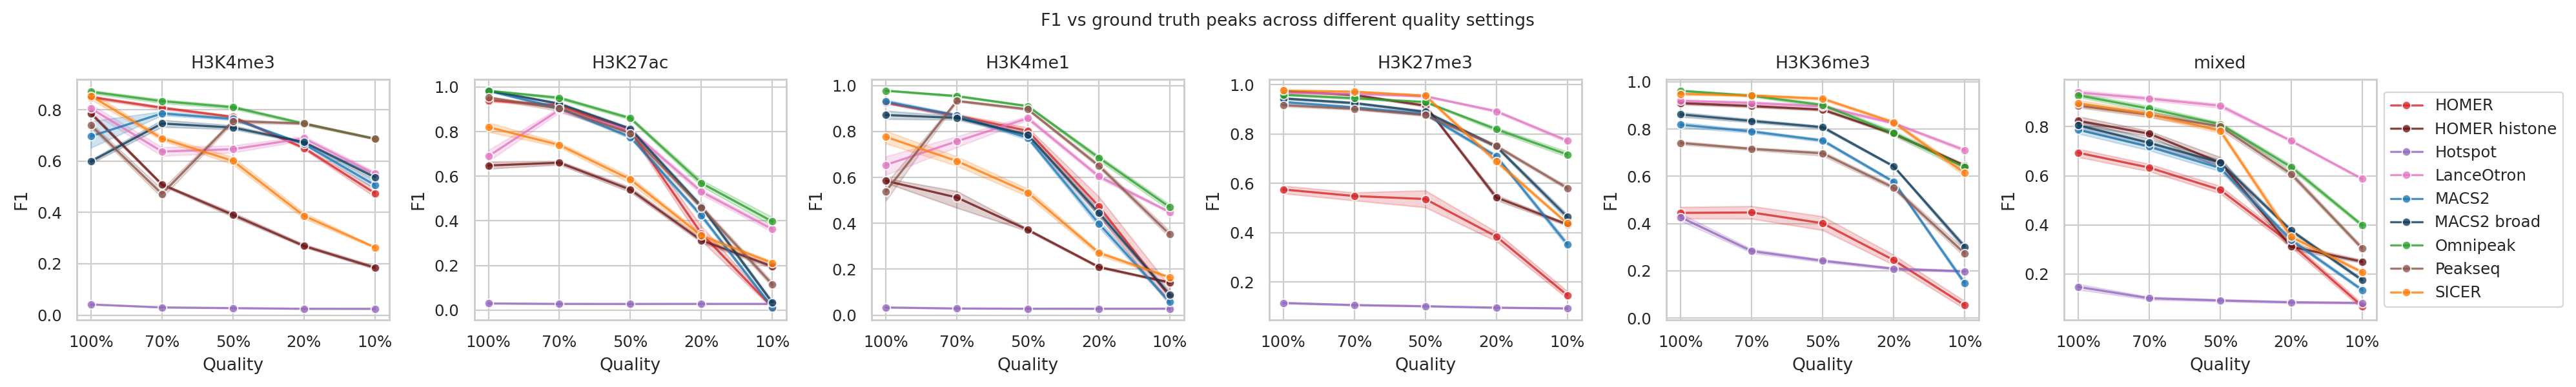

In [41]:
fig = plt.figure(figsize=(20, 3))
fig.suptitle("F1 vs ground truth peaks across different quality settings", fontsize="large")
axs = [plt.subplot(1, 6, i + 1) for i in range(6)]
labels = []  # Hack to add labels only once 
for i, m in enumerate(tqdm(MODIFICATIONS_MIXED)):
    ax = axs[i]
    for tool, dft in df_peaks[df_peaks['modification'] == m].groupby('tool'):
        if m == 'mixed' and tool not in labels:
            sns.lineplot(dft, x='quality', y='F1', marker='o', label=tool, color=TOOLS_PALETTE[tool], alpha=0.8, ax=ax)
            labels.append(tool)
        else:
            sns.lineplot(dft, x='quality', y='F1', marker='o', label=tool, color=TOOLS_PALETTE[tool], alpha=0.8, ax=ax)
    ax.set_xlabel('Quality')
    ax.set_ylabel('F1')
    ax.set_title(f'{m}')
    # Put a legend to the right of the current axis
    if i == 5:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))        
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'auc.pdf'), bbox_inches='tight', dpi=300)
plt.show()

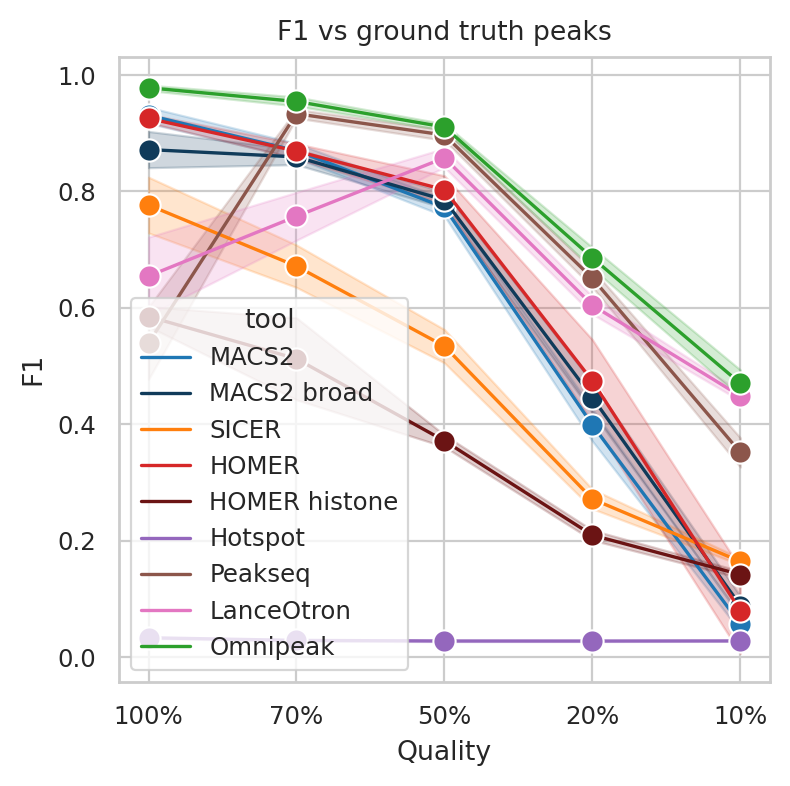

In [42]:
plt.figure(figsize=(4, 4))
sns.lineplot(data=df_peaks[df_peaks['modification'] == 'H3K4me1'], x="quality", y="F1", hue='tool',
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             errorbar='sd', marker='o', markersize=8)
plt.title('F1 vs ground truth peaks')
plt.xlabel('Quality')
plt.ylabel('F1')
plt.tight_layout()
plt.show()

In [43]:
t = []
for (m, n, tool), dft in tqdm(list(df_peaks0[df_peaks0['quality'] != '0%'].groupby(['modification', 'n', 'tool']))):
    aj = 0
    mprev = 0
    f1prev = 0
    for _, row in dft.sort_values(by=['multiplier']).iterrows():
        aj += (row['multiplier'] - mprev) * (row['F1'] + f1prev) / 2
        mprev, f1prev = row['multiplier'], row['F1']
    t.append((m, n, tool, aj))
dff1auc = pd.DataFrame(data=t, columns=['modification', 'n', 'tool', 'AUC'])
dff1auc.sample(3)

  0%|          | 0/540 [00:00<?, ?it/s]

,modification,n,tool,AUC
212,H3K36me3,4,MACS2 broad,0.698898
321,H3K4me1,6,Omnipeak,0.793537
302,H3K4me1,4,MACS2 broad,0.641957


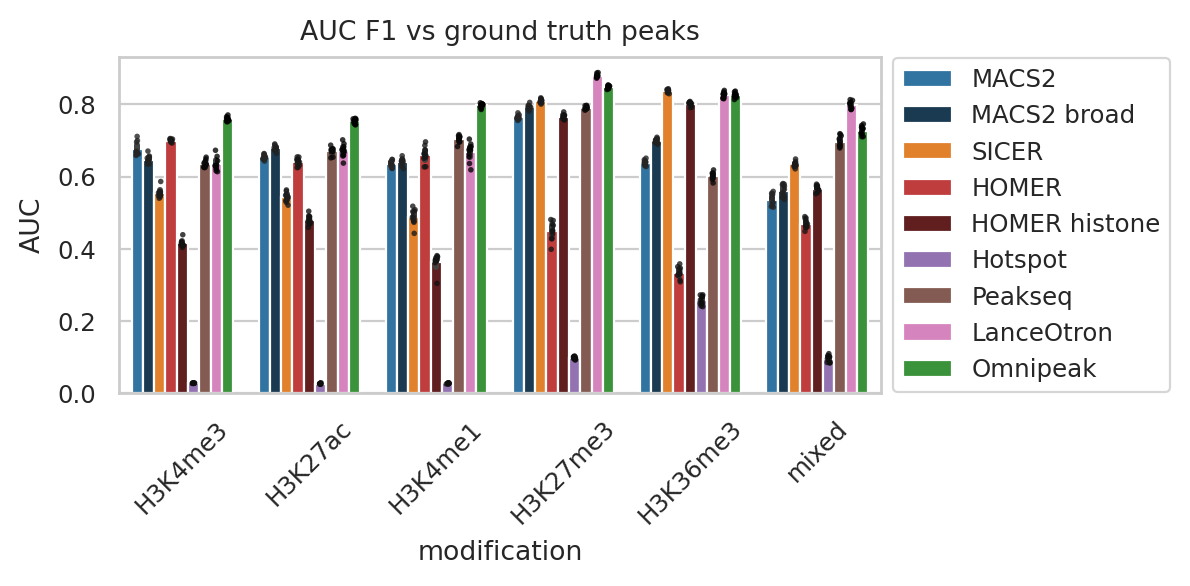

In [44]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
ax.title.set_text('AUC F1 vs ground truth peaks')
sns.barplot(data=dff1auc, x='modification', y='AUC', hue='tool',
            # capsize=.05, err_kws={'linewidth': 2},
            palette=TOOLS_PALETTE,
            order=MODIFICATIONS_MIXED,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=dff1auc, x='modification', y='AUC', hue='tool',
              dodge=True, size=2, color="black", alpha=0.8,
              palette="dark:black",
              order=MODIFICATIONS_MIXED,
              hue_order=TOOLS, legend=False,
              ax=ax)
ax.xaxis.set_tick_params(rotation=45)
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'jaccard_auc2.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Overlap vs 100% quality peaks

In [45]:
def compare_with_high_quality(df):
    rows = []
    for (m, n, t), dft in tqdm(list(df.groupby(['modification', 'n', 'tool']))):
        print(m, n, t)
        try:
            file100 = dft[dft['multiplier'] == 1.0]['file'].values[0]
        except:
            print(f'Failed to find 100% quality peaks for {m} {n} {t}')
            continue
        peaks_file100, peaks100, length100 = load(sorted_file(file100))
        for _, (f, mult) in dft[dft['multiplier'] != 1.0][['file', 'multiplier']].iterrows():
            file, peaks, length = load(sorted_file(f))
            overlap100 = len(peaks_file100.overlap(file))
            overlap = len(file.overlap(peaks_file100))
            overlap_len = peaks_file100.intersect(file).lengths().sum()
            rows.append((m, n, t, mult, file100, peaks100, length100, peaks, length, overlap100, overlap, overlap_len))

    overlap100_df = pd.DataFrame(rows, columns=['modification', 'n', 'tool', 'multiplier',
                                 'peaks_file100', 'peaks100', 'length100',
                                 'peaks', 'length',
                                 'overlap100', 'overlap', 'overlap_len'])
    del rows

    overlap100_df['Precision'] = overlap100_df['overlap'] / overlap100_df['peaks']
    overlap100_df['Recall'] = overlap100_df['overlap100'] / overlap100_df['peaks100']
    overlap100_df['F1'] = [2 / (1 / p + 1 / r) if min(p, r) > 0 else 0 for p, r in zip(overlap100_df['Precision'], overlap100_df['Recall'])]
    overlap100_df['Jaccard'] = overlap100_df['overlap_len'] / (overlap100_df['length100'] + overlap100_df['length'] - overlap100_df['overlap_len'])
    overlap100_df['quality'] = [f'{int(m * 100)}%' for m in overlap100_df['multiplier']]
    return overlap100_df


In [ ]:
overlap100_df_path = PATH + '/overlap100_df.tsv'
# ! rm {overlap100_df_path}
overlap100_df = load_or_compute(overlap100_df_path, lambda : compare_with_high_quality(df_peaks))
overlap100_df.sample(3)

rm: cannot remove '/home/jetbrains/data/2025_chips/overlap100_df.tsv': No such file or directory


  0%|          | 0/540 [00:00<?, ?it/s]

H3K27ac 1 HOMER
H3K27ac 1 HOMER histone
H3K27ac 1 Hotspot
H3K27ac 1 LanceOtron
H3K27ac 1 MACS2
H3K27ac 1 MACS2 broad
H3K27ac 1 Omnipeak
H3K27ac 1 Peakseq
H3K27ac 1 SICER
H3K27ac 2 HOMER
H3K27ac 2 HOMER histone
H3K27ac 2 Hotspot
H3K27ac 2 LanceOtron
H3K27ac 2 MACS2
H3K27ac 2 MACS2 broad
H3K27ac 2 Omnipeak
H3K27ac 2 Peakseq
H3K27ac 2 SICER
H3K27ac 3 HOMER
H3K27ac 3 HOMER histone
H3K27ac 3 Hotspot
H3K27ac 3 LanceOtron
H3K27ac 3 MACS2
H3K27ac 3 MACS2 broad
H3K27ac 3 Omnipeak
H3K27ac 3 Peakseq
H3K27ac 3 SICER
H3K27ac 4 HOMER
H3K27ac 4 HOMER histone
H3K27ac 4 Hotspot
H3K27ac 4 LanceOtron
H3K27ac 4 MACS2
H3K27ac 4 MACS2 broad
H3K27ac 4 Omnipeak
H3K27ac 4 Peakseq
H3K27ac 4 SICER
H3K27ac 5 HOMER
H3K27ac 5 HOMER histone
H3K27ac 5 Hotspot
H3K27ac 5 LanceOtron
H3K27ac 5 MACS2
H3K27ac 5 MACS2 broad
H3K27ac 5 Omnipeak
H3K27ac 5 Peakseq
H3K27ac 5 SICER
H3K27ac 6 HOMER
H3K27ac 6 HOMER histone
H3K27ac 6 Hotspot
H3K27ac 6 LanceOtron
H3K27ac 6 MACS2
H3K27ac 6 MACS2 broad
H3K27ac 6 Omnipeak
H3K27ac 6 Peak

In [47]:
overlap100_df0 = overlap100_df.copy()
# Add 1.0 and 0.0 multiplier
for m, n, tool in product(MODIFICATIONS_MIXED, range(1, N+1), TOOLS):
    row = [m, n, tool, 0.0] + [None] * (len(overlap100_df0.columns) - 4)
    overlap100_df0.loc[len(overlap100_df0)] = row
    row = [m, n, tool, 1.0] + [None] * (len(overlap100_df0.columns) - 4)
    overlap100_df0.loc[len(overlap100_df0)] = row
    
overlap100_df0.loc[overlap100_df0['multiplier'] == 0, 'quality'] = '0%'
overlap100_df0.loc[overlap100_df0['multiplier'] == 1.0, 'quality'] = '100%'
overlap100_df0.loc[overlap100_df0['multiplier'] == 0, 'Jaccard'] = 0
overlap100_df0.loc[overlap100_df0['multiplier'] == 1.0, 'Jaccard'] = 1
overlap100_df0.sort_values(by=['modification', 'n', 'tool', 'multiplier'], ascending=False, inplace=True)
overlap100_df0.tail(6)

,modification,n,tool,multiplier,peaks_file100,peaks100,length100,peaks,length,overlap100,overlap,overlap_len,Precision,Recall,F1,Jaccard,quality
2347,H3K27ac,1,HOMER,1.0,None,None,None,None,None,None,None,None,None,None,None,1,100%
0,H3K27ac,1,HOMER,0.7,/home/jetbrains/data/2025_chips/homer/H3K27ac_...,547,149878,480,129600,406,406,73668,0.845833,0.74223,0.790652,0.357942,70%
1,H3K27ac,1,HOMER,0.5,/home/jetbrains/data/2025_chips/homer/H3K27ac_...,547,149878,337,157716,296,296,62978,0.878338,0.541133,0.669683,0.257457,50%
2,H3K27ac,1,HOMER,0.2,/home/jetbrains/data/2025_chips/homer/H3K27ac_...,547,149878,144,6048,34,34,1216,0.236111,0.062157,0.098408,0.00786,20%
3,H3K27ac,1,HOMER,0.1,/home/jetbrains/data/2025_chips/homer/H3K27ac_...,547,149878,2,104,0,0,0,0.0,0.0,0.0,0.0,10%
2346,H3K27ac,1,HOMER,0.0,None,None,None,None,None,None,None,None,None,None,None,0,0%


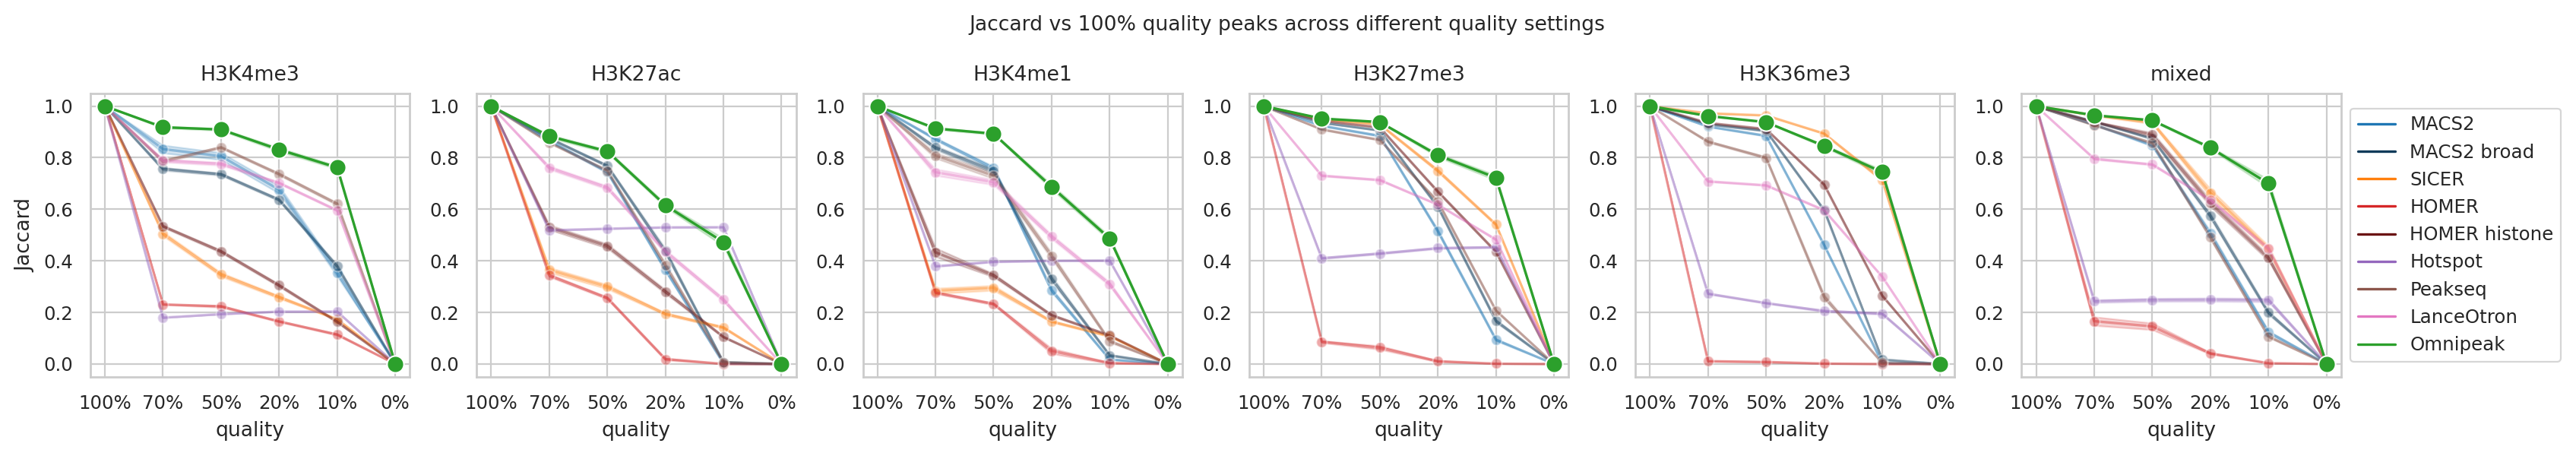

In [48]:
fig = plt.figure(figsize=(17, 3))
fig.suptitle("Jaccard vs 100% quality peaks across different quality settings", fontsize="large")
axs = [plt.subplot(1, 6, i + 1) for i in range(6)]
for i, m in enumerate(MODIFICATIONS_MIXED):
    ax = axs[i]
    sns.lineplot(data=overlap100_df0[(overlap100_df0['modification'] == m) &
                                     (overlap100_df0['tool'] != 'Omnipeak')], x="quality", y="Jaccard", hue='tool', ax=ax,
                 hue_order=TOOLS,
                 palette=TOOLS_PALETTE,
                 errorbar='se',
                 alpha=0.4,
                 marker='o', markersize=5,
                 sort=False)
    sns.lineplot(data=overlap100_df0[(overlap100_df0['modification'] == m) &
                                     (overlap100_df0['tool'] == 'Omnipeak')], x="quality", y="Jaccard", hue='tool', ax=ax,
                 hue_order=TOOLS,
                 palette=TOOLS_PALETTE, legend=False,
                 errorbar='se',
                 marker='o', markersize=8,
                 sort=False)
    
    ax.set_title(f'{m}')
    ax.set_ylim([-0.05, 1.05])
    # Put a legend to the right of the current axis
    if i == 5:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'jaccard2.pdf'), bbox_inches='tight', dpi=300)
plt.show()

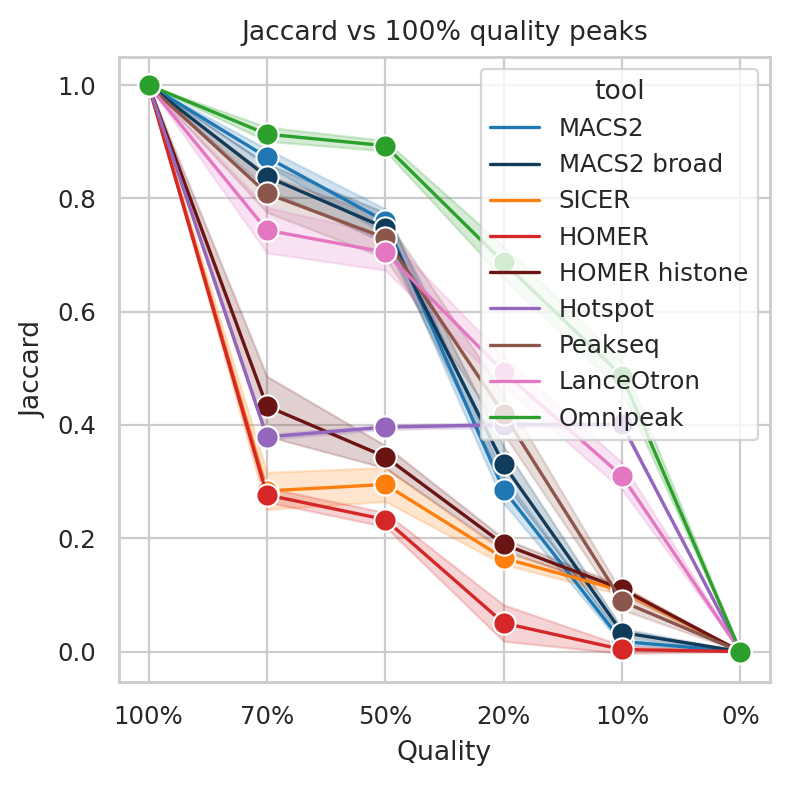

In [49]:
plt.figure(figsize=(4, 4))
sns.lineplot(data=overlap100_df0[overlap100_df0['modification'] == 'H3K4me1'], x="quality", y="Jaccard", hue='tool',
             hue_order=TOOLS,
             palette=TOOLS_PALETTE,
             errorbar='sd', marker='o', markersize=8)
plt.title('Jaccard vs 100% quality peaks')
plt.xlabel('Quality')
plt.ylabel('Jaccard')
plt.tight_layout()
plt.show()

In [50]:
t = []
for (m, n, tool), dft in tqdm(list(overlap100_df0[overlap100_df0['quality'] != '0%'].groupby(['modification', 'n', 'tool']))):
    aj = 0
    mprev = 0
    jprev = 0
    for _, row in dft.sort_values(by=['multiplier']).iterrows():
        aj += (row['multiplier'] - mprev) * (row['Jaccard'] + jprev) / 2
        mprev, jprev = row['multiplier'], row['Jaccard']
    t.append((m, n, tool, aj))
dfjaccardauc100 = pd.DataFrame(data=t, columns=['modification', 'n', 'tool', 'AUC'])
dfjaccardauc100.sample(3)

  0%|          | 0/540 [00:00<?, ?it/s]

,modification,n,tool,AUC
460,mixed,2,HOMER histone,0.785571
80,H3K27ac,9,SICER,0.360385
98,H3K27me3,1,SICER,0.812176


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

H3K36me3_LanceOtron vs. H3K36me3_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
mixed_LanceOtron vs. mixed_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K4me3_LanceOtron vs. H3K4me3_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K27ac_LanceOtron vs. H3K27ac_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K4me1_LanceOtron vs. H3K4me1_Omnipeak: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.827e-04 U_stat=0.000e+00
H3K27me3_LanceOtron vs. H3K27me3_Omnipeak: Mann-Whitney-Wilcoxon test two-s

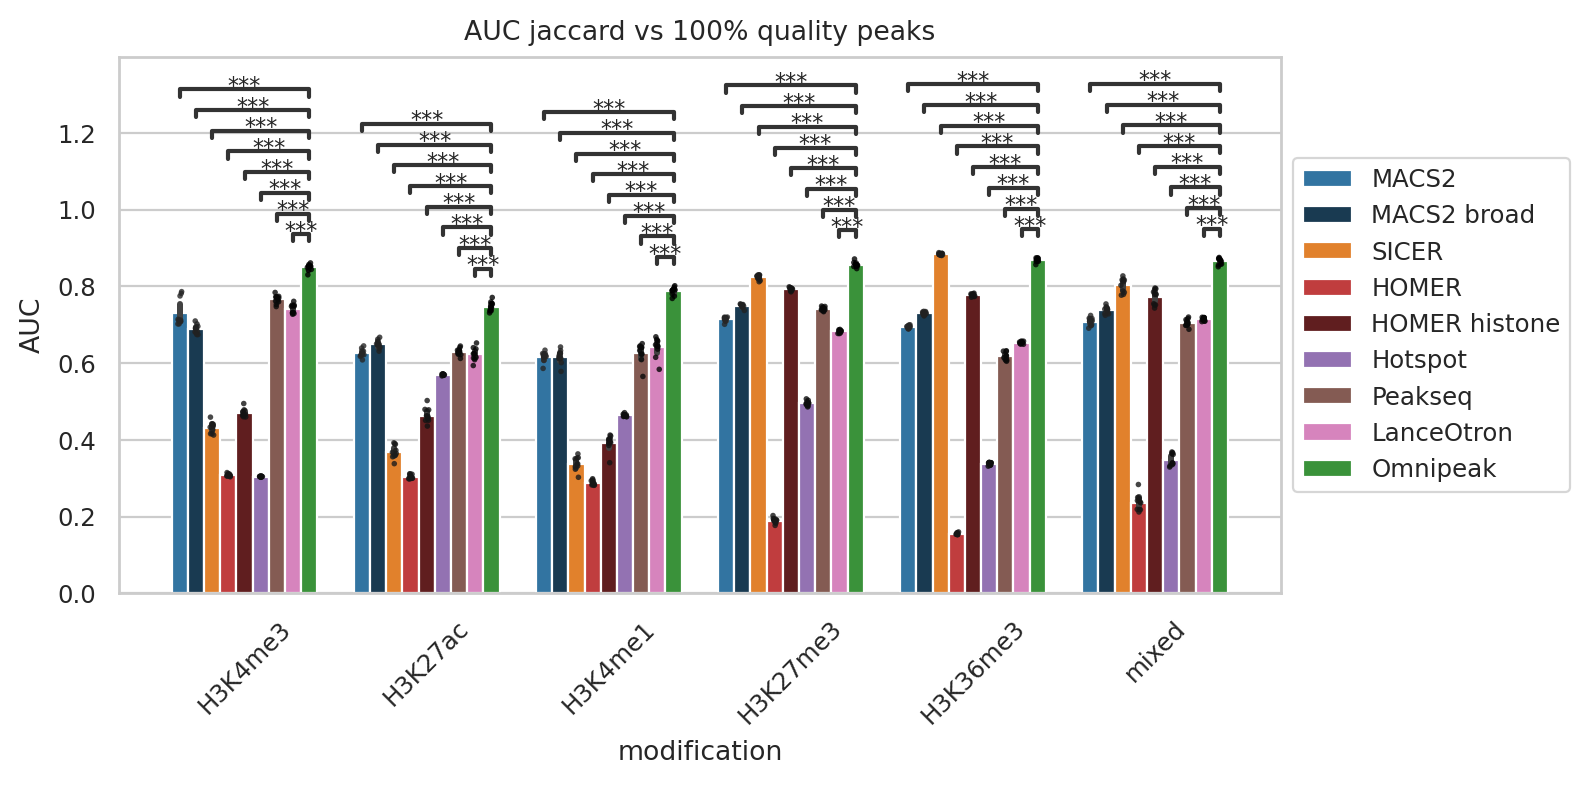

In [51]:
plt.figure(figsize=(8, 4))
ax = plt.axes()
ax.title.set_text('AUC jaccard vs 100% quality peaks')
sns.barplot(data=dfjaccardauc100, x='modification', y='AUC', hue='tool',
            # capsize=.05, err_kws={'linewidth': 2},
            order=MODIFICATIONS_MIXED,
            palette=TOOLS_PALETTE,
            hue_order=TOOLS,
            ax=ax)
sns.stripplot(data=dfjaccardauc100, x='modification', y='AUC', hue='tool',
              dodge=True, size=2, color="black", alpha=0.8, palette='dark:black',
              order=MODIFICATIONS_MIXED,
              hue_order=TOOLS, legend=False,
              ax=ax)
ax.xaxis.set_tick_params(rotation=45)
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

pairs = [((m, tl), (m, 'Omnipeak')) for m, tl in
         product(MODIFICATIONS_MIXED, [tool for tool in TOOLS if tool != 'Omnipeak'])]  # which groups to compare
annot = Annotator(ax, pairs, data=dfjaccardauc, x='modification', y='AUC', hue='tool',
                  order=MODIFICATIONS_MIXED, hue_order=TOOLS)
annot.configure(test='Mann-Whitney', comparisons_correction="BH", correction_format="replace",
                hide_non_significant=True,
                verbose=2,
                text_offset=-3, line_offset=0)
annot.apply_test()
annot.annotate()

plt.tight_layout()
# plt.savefig(os.path.join(FIGURES_DIR, f'jaccard_auc2.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# No control

In [58]:
TOOLS_NO_CONTROL = ['MACS2', 'MACS2 broad', 'SICER', 'HOMER', 'HOMER histone', 'Hotspot', 'LanceOtron', 'Omnipeak']

In [59]:
df_peaks_no_control = load_result_peaks(PATH + '_no_control')
df_peaks_no_control.sample()

0it [00:00, ?it/s]

MACS2 300


0it [00:00, ?it/s]

MACS2 broad 300


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Peakseq 0


0it [00:00, ?it/s]

LanceOtron 300


,file,modification,n,multiplier,tool,quality,peaks
388,/home/jetbrains/data/2025_chips_no_control/mac...,H3K27ac,8,0.2,MACS2 broad,20%,230


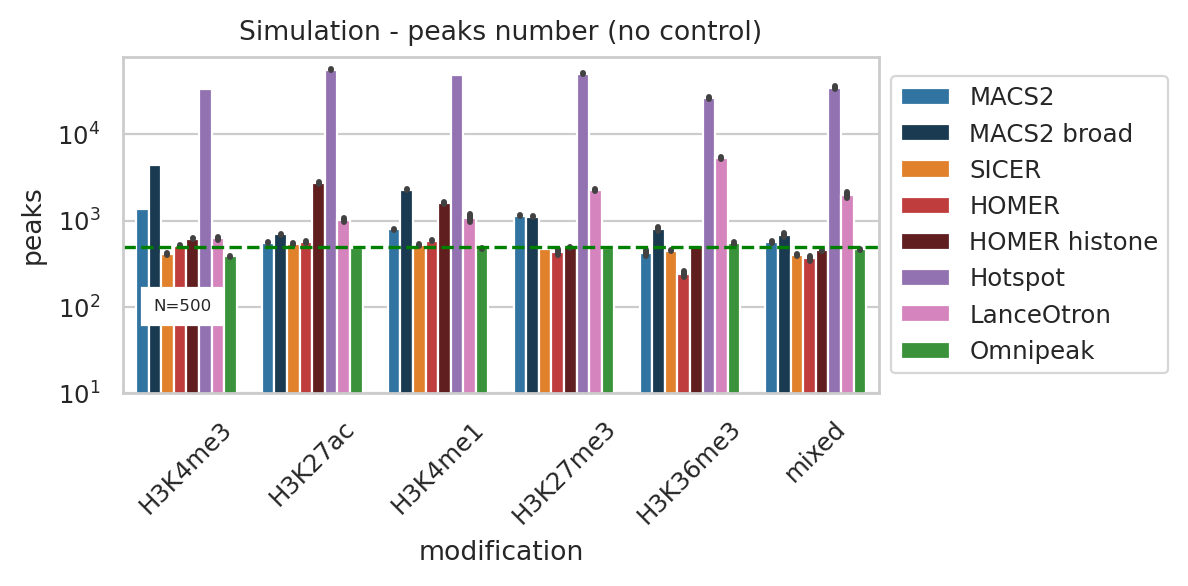

In [72]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
sns.barplot(data=df_peaks_no_control[df_peaks_no_control['quality'] == '100%'],
            x="modification", y="peaks", hue='tool', ax=ax,
            order=MODIFICATIONS_MIXED,
            hue_order=TOOLS_NO_CONTROL,
            palette=TOOLS_PALETTE, )
ax.xaxis.set_tick_params(rotation=45)
ax.set_title(f'Simulation - peaks number (no control)')
# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(10, 80_000)
ax.set(yscale='log')
ax.axhline(y=500, xmin=0, xmax=6, color='green', ls='dashed')
ax.text(0.04, 0.28, "N=500",
        transform=ax.transAxes, fontsize=6,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=1))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'peaks.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [61]:
df_lens_no_control = load_lens(df_peaks_no_control)
df_lens_no_control.sample(5)

,length,modification,quality,tool
1161434,500.0,H3K27me3,10%,HOMER histone
6304747,729.0,H3K36me3,20%,Hotspot
3047573,515.0,H3K27ac,100%,Hotspot
4482529,101.0,H3K27me3,50%,Hotspot
466800,1199.0,H3K4me3,70%,SICER


Simulation with control
without control


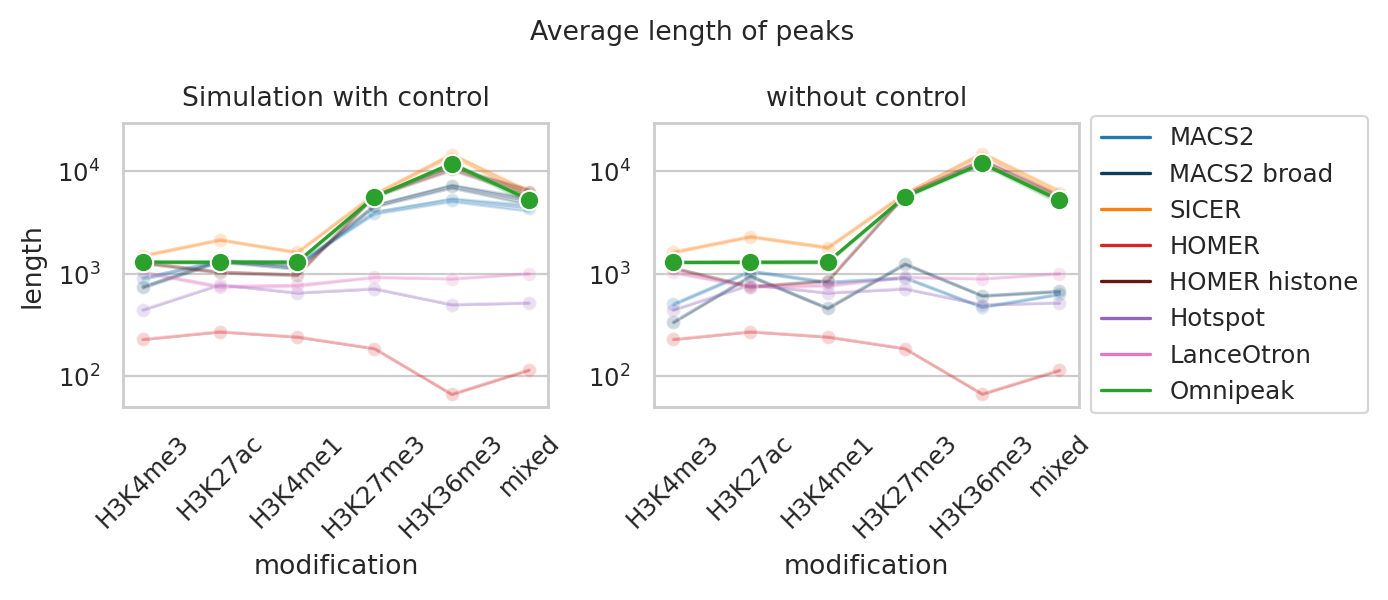

In [71]:
fig = plt.figure(figsize=(7, 3))
fig.suptitle("Average length of peaks", fontsize="large")
axs = [plt.subplot(1, 2, i + 1) for i in range(2)]
for i, (df, name) in enumerate(zip([df_lens[df_lens['quality'] == '100%'],
                                    df_lens_no_control[df_lens_no_control['quality'] == '100%']],
                                   ['Simulation with control', 'without control'])):
    ax = axs[i]
    print(name)
    t = df.copy()
    t['mindex'] = 0
    for j, m in enumerate(MODIFICATIONS_MIXED):
        t.loc[t['modification'] == m, 'mindex'] = j
    t = t.sort_values(by=['mindex', 'tool', 'length'])
    sns.lineplot(data=t[t['tool'] != 'Omnipeak'],
             y='length', x='mindex', hue='tool', orient='x',
             alpha=0.2,
             hue_order=TOOLS_NO_CONTROL,
             palette=TOOLS_PALETTE,
             marker='o', markersize=5,
             legend=False,
             ax=ax)
    sns.lineplot(data=t[t['tool'] == 'Omnipeak'],
             y='length', x='mindex', hue='tool', orient='x',
             alpha=1.0,
             hue_order=TOOLS_NO_CONTROL,
             palette=TOOLS_PALETTE,
             marker='o', markersize=7,
             legend=True,
             ax=ax)
    ax.set_xticks(range(6), minor=False)
    ax.set_xticklabels(MODIFICATIONS_MIXED, rotation=45)
    ax.set_xlabel('modification')
    ax.set_ylabel('length')
    ax.set(yscale='log')
    ax.set_ylim(50, 3e4)
    ax.title.set_text(f'{name}')
    ax.xaxis.set_tick_params(rotation=45)
    # Put a legend to the right of the current axis
    if i == len(axs) - 1:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.legend().set_visible(False)
    if i > 0:
        ax.set_ylabel(None)
    # Hide grid lines
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

In [63]:
df_peaks_no_control_path = PATH + 'peaks_no_control.tsv'
# ! rm {df_peaks_no_control_path}
df_peaks_no_control = load_or_compute(df_peaks_no_control_path,
                                      lambda :compare_with_ground_truth(df_peaks_no_control))
df_peaks_no_control.sample(5)

rm: cannot remove '/home/jetbrains/data/2025_chipspeaks_no_control.tsv': No such file or directory
Loading true files...


  0%|          | 0/2400 [00:00<?, ?it/s]

Computing overlap...


  0%|          | 0/2400 [00:00<?, ?it/s]

,file,modification,n,multiplier,tool,quality,peaks,m,true_peaks_file,true_peaks,true_length,length,true_overlap,overlap,overlap_len,Precision,Recall,F1,Jaccard
1639,/home/jetbrains/data/2025_chips_no_control/hom...,H3K4me1,8,0.1,HOMER histone,10%,4275,H3K4me1,/home/jetbrains/data/2025_chips/fastq/H3K4me1_...,500,593398,2852774,331,337,465087,0.078830,0.662,0.140884,0.156013
1741,/home/jetbrains/data/2025_chips_no_control/hom...,H3K36me3,9,0.7,HOMER histone,70%,523,H3K36me3,/home/jetbrains/data/2025_chips/fastq/H3K36me3...,500,6440700,6285491,473,523,6192859,1.000000,0.946,0.972251,0.947887
1997,/home/jetbrains/data/2025_chips_no_control/hot...,H3K27me3,10,0.5,Hotspot,50%,57667,H3K27me3,/home/jetbrains/data/2025_chips/fastq/H3K27me3...,500,2813300,46101180,498,3144,2722911,0.054520,0.996,0.103381,0.058948
954,/home/jetbrains/data/2025_chips_no_control/sic...,H3K27ac,1,0.1,SICER,10%,694,H3K27ac,/home/jetbrains/data/2025_chips/fastq/H3K27ac_...,500,534424,1607906,166,167,335709,0.240634,0.332,0.279028,0.185821
2360,/home/jetbrains/data/2025_chips_no_control/lan...,mixed,3,1.0,LanceOtron,100%,2165,mixed,/home/jetbrains/data/2025_chips/fastq/mixed_k4...,500,2534666,2085114,426,2165,1994047,1.000000,0.852,0.920086,0.759425


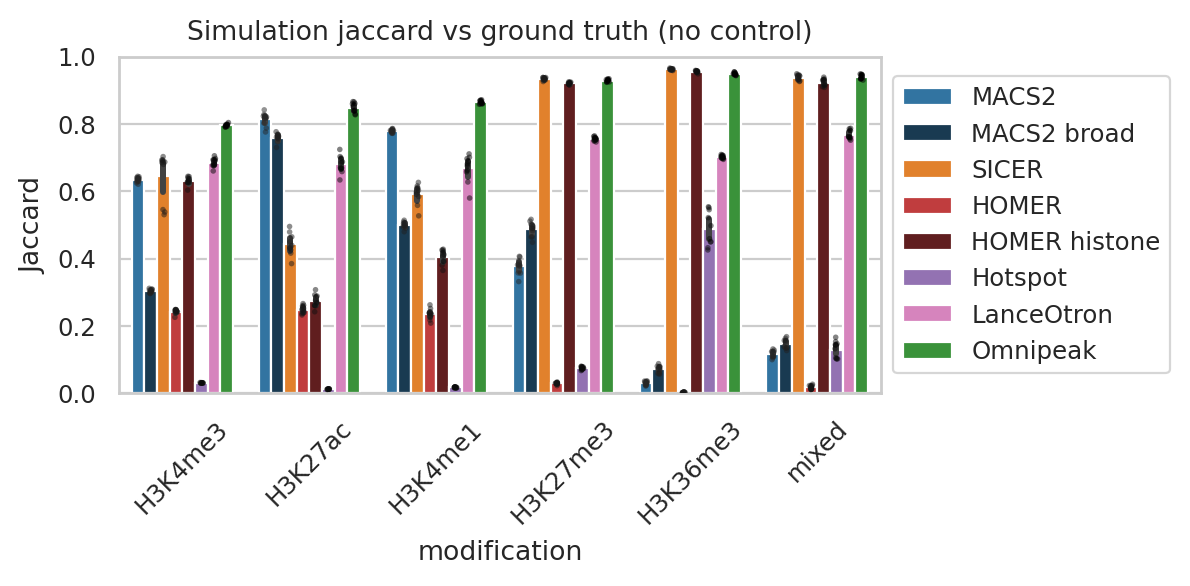

In [64]:
plt.figure(figsize=(6, 3))
ax = plt.axes()
t = df_peaks_no_control[df_peaks_no_control['quality'] == '100%']
sns.barplot(data=t,
            x='modification', y='Jaccard', hue='tool',
            hue_order=TOOLS_NO_CONTROL,
            palette=TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t,
              x='modification', y='Jaccard', hue='tool',
              dodge=True, size=2, color="black", alpha=0.5, palette='dark:black',
              hue_order=TOOLS_NO_CONTROL,
              legend=False,
              ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Simulation jaccard vs ground truth (no control)')
ax.xaxis.set_tick_params(rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'jaccard3.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Ratio without / with control

In [65]:
t = df_peaks_no_control[['modification', 'n', 'multiplier', 'quality', 'tool', 'file']].copy()
t.rename(columns={'file': 'file_no_control'}, inplace=True)
df_peaks_with_without_control = pd.merge(t, df_peaks[['modification', 'n', 'multiplier', 'quality', 'tool', 'file']],
                                         on=['modification', 'n', 'multiplier', 'quality', 'tool'], how='inner')
del t
df_peaks_with_without_control.sample(3)

,modification,n,multiplier,quality,tool,file_no_control,file
1141,H3K36me3,9,0.7,70%,SICER,/home/jetbrains/data/2025_chips_no_control/sic...,/home/jetbrains/data/2025_chips/sicer/H3K36me3...
1143,H3K36me3,9,0.2,20%,SICER,/home/jetbrains/data/2025_chips_no_control/sic...,/home/jetbrains/data/2025_chips/sicer/H3K36me3...
628,H3K4me3,6,0.2,20%,Omnipeak,/home/jetbrains/data/2025_chips_no_control/omn...,/home/jetbrains/data/2025_chips/omnipeak/H3K4m...


In [78]:
rows = []
for _, row in tqdm(list(df_peaks_with_without_control.iterrows())):
    m, n, mult, q, t, f_with_control, f_without_control =\
        row['modification'], row['n'], row['multiplier'], row['quality'], row['tool'], row['file'], row['file_no_control']
    print(m, n, mult, q, t)
    peaks_with_control = lines(f_with_control)
    peaks_without_control = lines(f_without_control)
    rows.append((m, n, mult, q, t, d(peaks_without_control - peaks_with_control + 1, peaks_without_control + peaks_with_control + 1)))
df_ratio = pd.DataFrame(rows, columns=['modification', 'n', 'multiplier', 'quality', 'tool', 'ratio'])
# df_ratio['ratio'] = ((df_ratio['ratio'] - 1) * 100).astype(int)
del rows
df_ratio.sample(3)

  0%|          | 0/2400 [00:00<?, ?it/s]

H3K4me3 1 1.0 100% MACS2
H3K4me3 1 0.7 70% MACS2
H3K4me3 1 0.5 50% MACS2
H3K4me3 1 0.2 20% MACS2
H3K4me3 1 0.1 10% MACS2
H3K4me3 2 1.0 100% MACS2
H3K4me3 2 0.7 70% MACS2
H3K4me3 2 0.5 50% MACS2
H3K4me3 2 0.2 20% MACS2
H3K4me3 2 0.1 10% MACS2
H3K4me3 3 1.0 100% MACS2
H3K4me3 3 0.7 70% MACS2
H3K4me3 3 0.5 50% MACS2
H3K4me3 3 0.2 20% MACS2
H3K4me3 3 0.1 10% MACS2
H3K4me3 4 1.0 100% MACS2
H3K4me3 4 0.7 70% MACS2
H3K4me3 4 0.5 50% MACS2
H3K4me3 4 0.2 20% MACS2
H3K4me3 4 0.1 10% MACS2
H3K4me3 5 1.0 100% MACS2
H3K4me3 5 0.7 70% MACS2
H3K4me3 5 0.5 50% MACS2
H3K4me3 5 0.2 20% MACS2
H3K4me3 5 0.1 10% MACS2
H3K4me3 6 1.0 100% MACS2
H3K4me3 6 0.7 70% MACS2
H3K4me3 6 0.5 50% MACS2
H3K4me3 6 0.2 20% MACS2
H3K4me3 6 0.1 10% MACS2
H3K4me3 7 1.0 100% MACS2
H3K4me3 7 0.7 70% MACS2
H3K4me3 7 0.5 50% MACS2
H3K4me3 7 0.2 20% MACS2
H3K4me3 7 0.1 10% MACS2
H3K4me3 8 1.0 100% MACS2
H3K4me3 8 0.7 70% MACS2
H3K4me3 8 0.5 50% MACS2
H3K4me3 8 0.2 20% MACS2
H3K4me3 8 0.1 10% MACS2
H3K4me3 9 1.0 100% MACS2
H3K4me3

,modification,n,multiplier,quality,tool,ratio
919,H3K4me3,4,0.1,10%,SICER,-0.418900
602,H3K4me3,1,0.5,50%,Omnipeak,0.004367
859,mixed,2,0.1,10%,Omnipeak,0.080332


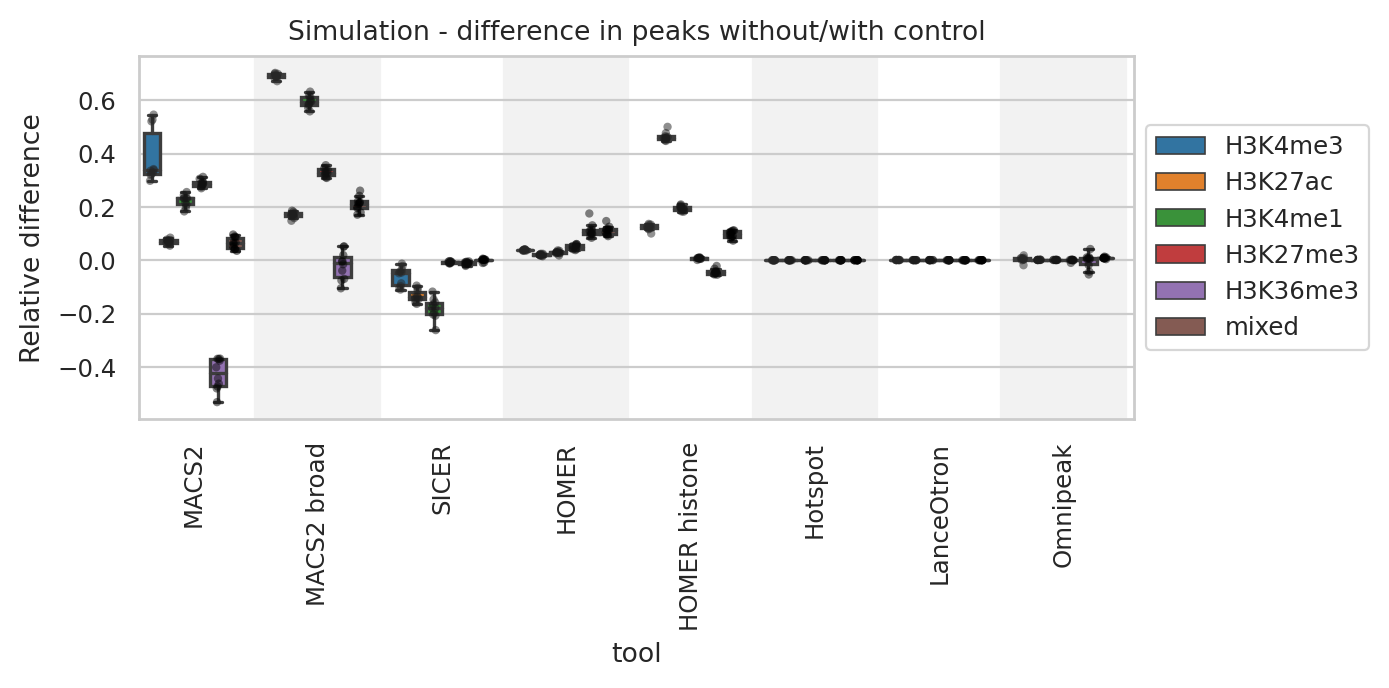

In [79]:
plt.figure(figsize=(7, 3.5))
ax = plt.axes()
t = df_ratio[df_ratio['quality'] == '100%']
sns.boxplot(data=t,
            x='tool', y='ratio', hue='modification',
            showfliers=False,
            hue_order=MODIFICATIONS_MIXED,
            order=TOOLS_NO_CONTROL,
            # palette = TOOLS_PALETTE,
            ax=ax)
sns.stripplot(data=t,
              x='tool', y='ratio', hue='modification',
              dodge=True, size=3, color="black", alpha=0.5, palette='dark:black',
              hue_order=MODIFICATIONS_MIXED,
              order=TOOLS_NO_CONTROL,
              legend=False,
              ax=ax)

ax.set_ylabel('Relative difference')
ax.xaxis.set_tick_params(rotation=90)
# ax.set_ylim(-150, 200)
ax.set_title('Simulation - difference in peaks without/with control')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Add light-grey bands for odd categories
for k in range(len(ax.get_xticks())):
    if k % 2:  # odd
        ax.axvspan(k - 0.5, k + 0.5, zorder=0, color="0.95")

plt.tight_layout()
plt.show()

# Jaccard without / with control

In [68]:
def compute_jaccard_with_without_control(df_peaks_with_without_control):
    rows = []
    for _, (m, n, mult, q, t, f_with_control, f_without_control) in tqdm(list(df_peaks_with_without_control.iterrows())):
        t2 = df_peaks_no_control[(df_peaks_no_control['modification'] == m) &
                                (df_peaks_no_control['n'] == n) &
                                (df_peaks_no_control['multiplier'] == mult) &
                                (df_peaks_no_control['tool'] == t)]
        print(m, n, mult, q, t)
        with_control, peaks_with_control, len_with_control = load(sorted_file(f_with_control))
        without_control, peaks_without_control, len_without_control = load(sorted_file(f_without_control))
        overlap_len = with_control.intersect(without_control).lengths().sum()
        jaccard = d(overlap_len, len_with_control + len_without_control - overlap_len)
        rows.append((m, n, mult, q, t, peaks_with_control, peaks_without_control, len_with_control, len_without_control,
                     d(len_with_control, peaks_with_control), d(len_without_control, peaks_without_control),
                     overlap_len, jaccard))
    df_jaccard = pd.DataFrame(rows, columns=['modification', 'n', 'multiplier', 'quality', 'tool',
                                             'peaks_with_control', 'peaks_without_control',
                                             'len_with_control', 'len_without_control',
                                             'avg_len_with_control', 'avg_len_without_control',
                                             'overlap_len', 'jaccard'])
    del rows
    return df_jaccard

In [69]:
df_jaccard_path = PATH + '/df_jaccard_without_control.tsv'
df_jaccard = load_or_compute(df_jaccard_path,
                             lambda: compute_jaccard_with_without_control(df_peaks_with_without_control))
df_jaccard.sample(3)

  0%|          | 0/2400 [00:00<?, ?it/s]

H3K4me3 1 1.0 100% MACS2
H3K4me3 1 0.7 70% MACS2
H3K4me3 1 0.5 50% MACS2
H3K4me3 1 0.2 20% MACS2
H3K4me3 1 0.1 10% MACS2
H3K4me3 2 1.0 100% MACS2
H3K4me3 2 0.7 70% MACS2
H3K4me3 2 0.5 50% MACS2
H3K4me3 2 0.2 20% MACS2
H3K4me3 2 0.1 10% MACS2
H3K4me3 3 1.0 100% MACS2
H3K4me3 3 0.7 70% MACS2
H3K4me3 3 0.5 50% MACS2
H3K4me3 3 0.2 20% MACS2
H3K4me3 3 0.1 10% MACS2
H3K4me3 4 1.0 100% MACS2
H3K4me3 4 0.7 70% MACS2
H3K4me3 4 0.5 50% MACS2
H3K4me3 4 0.2 20% MACS2
H3K4me3 4 0.1 10% MACS2
H3K4me3 5 1.0 100% MACS2
H3K4me3 5 0.7 70% MACS2
H3K4me3 5 0.5 50% MACS2
H3K4me3 5 0.2 20% MACS2
H3K4me3 5 0.1 10% MACS2
H3K4me3 6 1.0 100% MACS2
H3K4me3 6 0.7 70% MACS2
H3K4me3 6 0.5 50% MACS2
H3K4me3 6 0.2 20% MACS2
H3K4me3 6 0.1 10% MACS2
H3K4me3 7 1.0 100% MACS2
H3K4me3 7 0.7 70% MACS2
H3K4me3 7 0.5 50% MACS2
H3K4me3 7 0.2 20% MACS2
H3K4me3 7 0.1 10% MACS2
H3K4me3 8 1.0 100% MACS2
H3K4me3 8 0.7 70% MACS2
H3K4me3 8 0.5 50% MACS2
H3K4me3 8 0.2 20% MACS2
H3K4me3 8 0.1 10% MACS2
H3K4me3 9 1.0 100% MACS2
H3K4me3

,modification,n,multiplier,quality,tool,peaks_with_control,peaks_without_control,len_with_control,len_without_control,avg_len_with_control,avg_len_without_control,overlap_len,jaccard
416,H3K4me1,4,0.7,70%,MACS2 broad,598,414,637481,601255,1066.021739,1452.306763,538901,0.77004
1845,H3K4me3,10,1.0,100%,Hotspot,33749,33749,15020208,15020208,445.056387,445.056387,15020208,1.00000
2115,H3K4me3,4,1.0,100%,LanceOtron,600,600,647426,647426,1079.043333,1079.043333,647426,1.00000


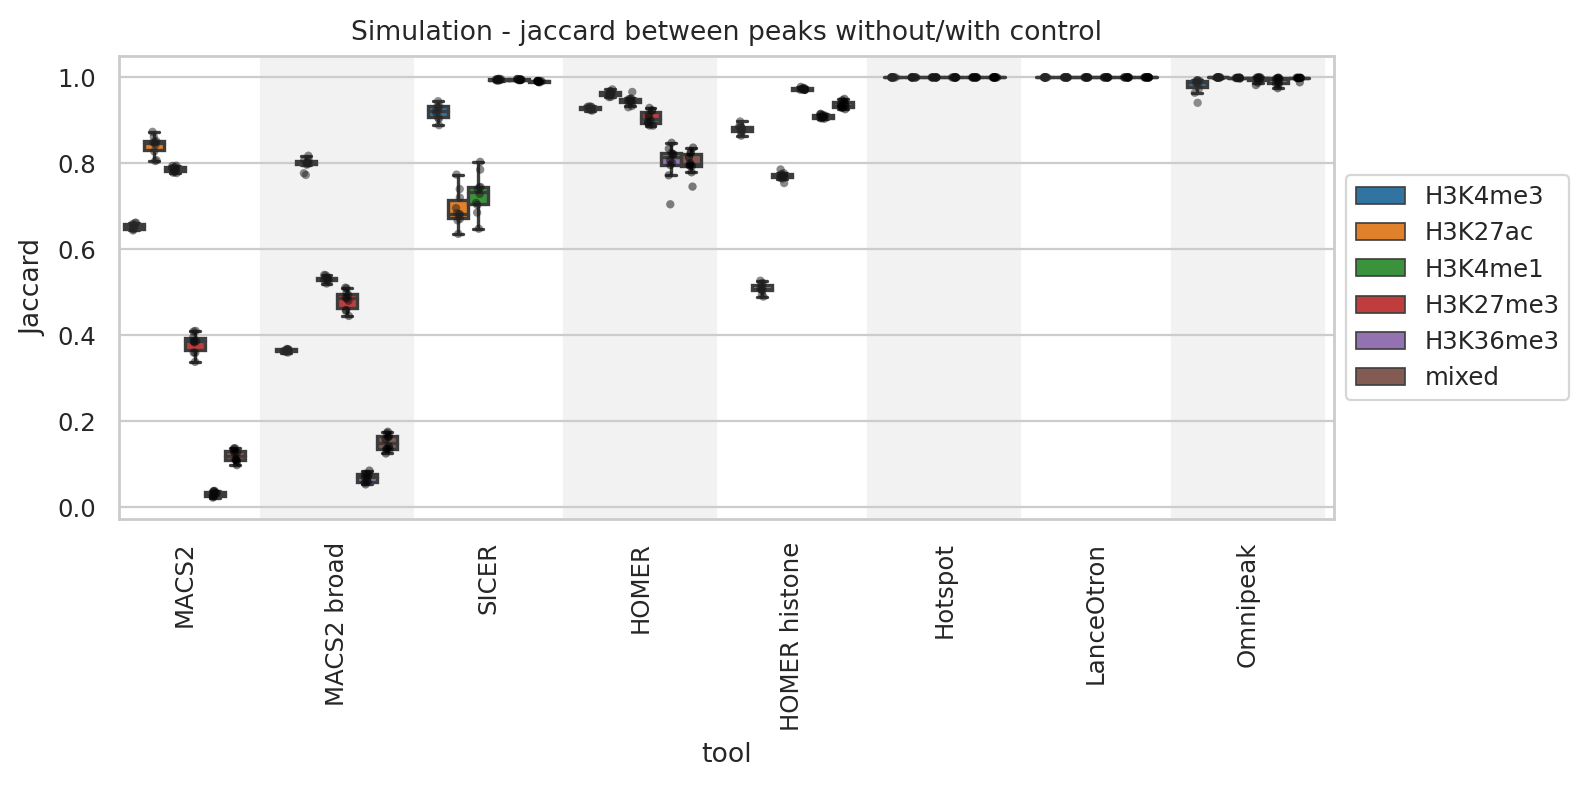

In [74]:
plt.figure(figsize=(8, 4))
ax = plt.axes()
t = df_jaccard[df_jaccard['quality'] == '100%']
sns.boxplot(data=t,
            x='tool', y='jaccard', hue='modification',
            showfliers=False,
            hue_order=MODIFICATIONS_MIXED,
            order=TOOLS_NO_CONTROL,
            ax=ax)
sns.stripplot(data=t,
              x='tool', y='jaccard', hue='modification',
              dodge=True, size=3, color="black", alpha=0.5, palette='dark:black',
              hue_order=MODIFICATIONS_MIXED,
              order=TOOLS_NO_CONTROL,
              legend=False,
              ax=ax)
ax.set_ylabel('Jaccard')
ax.xaxis.set_tick_params(rotation=90)
# ax.set_ylim(-150, 200)
ax.set_title('Simulation - jaccard between peaks without/with control')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Add light-grey bands for odd categories
for k in range(len(ax.get_xticks())):
    if k % 2:  # odd
        ax.axvspan(k - 0.5, k + 0.5, zorder=0, color="0.95")
plt.tight_layout()
plt.show()

# DONE